# Toy example

This notebook is a toy workflow for modeling a tiered healthcare critical infrastructure nexus using Dynamic Bayesian Network under flooding.

The hospital system is represented by three-tier functionality nodes:

- Tier 1: acute care plus selected critical offsites such as RCC.
- Tier 2: large offsites and administrative buildings such as Gateway, Page Field, and University Highlands.
- Tier 3: all other sites.

## 0. Imports and helper functions

In [1]:
import math
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)

HURRICANE_EVENT_HOURS = 48
GENERATOR_RUNTIME_HOURS = 120
TIME_STEP_HOURS = 6


def normal_cdf(x):
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))


def lognormal_fragility(depth_m, median_depth_m, beta):
    if depth_m <= 0:
        return 0.0
    z = (math.log(depth_m) - math.log(median_depth_m)) / beta
    return normal_cdf(z)


def combine_independent_probabilities(*probabilities):
    survival = 1.0
    for p in probabilities:
        survival *= (1.0 - float(p))
    return 1.0 - survival


def bernoulli_prob(value, p_true):
    return p_true if value == 1 else (1.0 - p_true)


def noisy_or_failure(parent_failures, strengths, routine_failure_probability=0.0):
    """
    Noisy-OR with a routine failure probability obtained from logs.

    The routine term is not expert elicited; it is the observed normal-condition probability
    of the child being failed when the modeled event-specific causes are absent.
    """
    survival = 1.0 - routine_failure_probability
    for x, s in zip(parent_failures, strengths):
        if x == 1:
            survival *= (1.0 - s)
    return 1.0 - survival


def redundant_communication_failure(parent_failures, roles, routine_failure_probability):
    failed = dict(zip(roles, parent_failures))
    role_names = [r for r, _ in roles]

    if "co_primary" in role_names:
        total_co = sum(r == "co_primary" for r, _ in roles)
        available_co = sum(r == "co_primary" and x == 0 for (r, _), x in failed.items())
        if available_co > 0:
            return min(0.98, routine_failure_probability + 0.10 * (total_co - available_co))
        return 0.92

    primary_up = any(r == "primary" and x == 0 for (r, _), x in failed.items())
    backup_total = sum(r == "backup" for r, _ in roles)
    backup_up = sum(r == "backup" and x == 0 for (r, _), x in failed.items())
    backup_down = backup_total - backup_up

    if primary_up:
        return min(0.98, routine_failure_probability + 0.035 * backup_down)
    if backup_up > 0:
        return min(0.98, 0.18 + 0.08 * (backup_total - backup_up))
    return 0.95


def generator_buffered_power_failure(grid_failed, event_elapsed_hours, routine_failure_probability):
    if grid_failed == 0:
        return routine_failure_probability
    if event_elapsed_hours <= GENERATOR_RUNTIME_HOURS:
        return min(0.98, routine_failure_probability + 0.08)
    excess_days = (event_elapsed_hours - GENERATOR_RUNTIME_HOURS) / 24.0
    return min(0.98, 0.70 + 0.10 * excess_days)


def functionality_state_distribution(parent_failures, tier_params):
    p_ge_reduced = noisy_or_failure(
        parent_failures,
        tier_params["ge_reduced"]["strengths"],
        routine_failure_probability=tier_params["ge_reduced"]["routine_probability"],
    )
    p_ge_critical = noisy_or_failure(
        parent_failures,
        tier_params["ge_critical"]["strengths"],
        routine_failure_probability=tier_params["ge_critical"]["routine_probability"],
    )
    p_ge_failed = noisy_or_failure(
        parent_failures,
        tier_params["ge_failed"]["strengths"],
        routine_failure_probability=tier_params["ge_failed"]["routine_probability"],
    )
    p_ge_critical = min(p_ge_critical, p_ge_reduced)
    p_ge_failed = min(p_ge_failed, p_ge_critical)
    return {
        "Normal": 1.0 - p_ge_reduced,
        "Reduced": p_ge_reduced - p_ge_critical,
        "Critical": p_ge_critical - p_ge_failed,
        "Failed": p_ge_failed,
    }

## 1. Raw data inputs

In [2]:
asset_inventory = pd.DataFrame([
    {"node_id": "TIER1_SITES", "node_type": "FacilityTier", "tier": "Tier 1", "name": "Acute care and RCC-like critical sites", "operator": "Toy Health", "lat": 26.60, "lon": -81.87, "elevation_m": 3.0},
    {"node_id": "TIER2_SITES", "node_type": "FacilityTier", "tier": "Tier 2", "name": "Large offsites and administrative buildings", "operator": "Toy Health", "lat": 26.62, "lon": -81.86, "elevation_m": 2.8},
    {"node_id": "TIER3_SITES", "node_type": "FacilityTier", "tier": "Tier 3", "name": "All other sites", "operator": "Toy Health", "lat": 26.64, "lon": -81.89, "elevation_m": 2.6},
    {"node_id": "PP_1", "node_type": "PowerPlant", "tier": "Shared", "name": "Toy Power Plant", "operator": "Utility A", "lat": 26.65, "lon": -81.80, "elevation_m": 2.5},
    {"node_id": "SUB_1", "node_type": "Substation", "tier": "Shared", "name": "Toy Substation", "operator": "Utility A", "lat": 26.62, "lon": -81.84, "elevation_m": 2.0},
    {"node_id": "WTP_1", "node_type": "WaterTreatmentPlant", "tier": "Shared", "name": "Toy Water Treatment Plant", "operator": "Water Utility B", "lat": 26.58, "lon": -81.90, "elevation_m": 2.2},
    {"node_id": "LEE_DARK_FIBER", "node_type": "DarkFiberHub", "tier": "Tier 1 primary", "name": "Dual redundant Lee County dark fiber", "operator": "Lee County", "lat": 26.61, "lon": -81.86, "elevation_m": 3.2},
    {"node_id": "LUMEN_MPLS", "node_type": "TelecomProviderNode", "tier": "Tier 1 backup; Tier 2 co-primary; Tier 3 primary", "name": "Lumen MPLS", "operator": "Lumen", "lat": 26.63, "lon": -81.85, "elevation_m": 2.4},
    {"node_id": "COMCAST_ENS", "node_type": "TelecomProviderNode", "tier": "Tier 1 backup; Tier 2 co-primary", "name": "Comcast ENS", "operator": "Comcast", "lat": 26.64, "lon": -81.88, "elevation_m": 2.1},
    {"node_id": "COMCAST_BUSINESS", "node_type": "TelecomProviderNode", "tier": "Tier 3 backup", "name": "Comcast Business", "operator": "Comcast", "lat": 26.57, "lon": -81.82, "elevation_m": 1.7},
    {"node_id": "TMOBILE_5G", "node_type": "WirelessProviderNode", "tier": "Tier 3 backup", "name": "T-Mobile 5G", "operator": "T-Mobile", "lat": 26.59, "lon": -81.83, "elevation_m": 2.9},
])

asset_inventory

,node_id,node_type,tier,name,operator,lat,lon,elevation_m
0,TIER1_SITES,FacilityTier,Tier 1,Acute care and RCC-like critical sites,Toy Health,26.60,-81.87,3.0
1,TIER2_SITES,FacilityTier,Tier 2,Large offsites and administrative buildings,Toy Health,26.62,-81.86,2.8
2,TIER3_SITES,FacilityTier,Tier 3,All other sites,Toy Health,26.64,-81.89,2.6
3,PP_1,PowerPlant,Shared,Toy Power Plant,Utility A,26.65,-81.80,2.5
4,SUB_1,Substation,Shared,Toy Substation,Utility A,26.62,-81.84,2.0
5,WTP_1,WaterTreatmentPlant,Shared,Toy Water Treatment Plant,Water Utility B,26.58,-81.90,2.2
6,LEE_DARK_FIBER,DarkFiberHub,Tier 1 primary,Dual redundant Lee County dark fiber,Lee County,26.61,-81.86,3.2
7,LUMEN_MPLS,TelecomProviderNode,Tier 1 backup; Tier 2 co-primary; Tier 3 primary,Lumen MPLS,Lumen,26.63,-81.85,2.4
8,COMCAST_ENS,TelecomProviderNode,Tier 1 backup; Tier 2 co-primary,Comcast ENS,Comcast,26.64,-81.88,2.1
9,COMCAST_BUSINESS,TelecomProviderNode,Tier 3 backup,Comcast Business,Comcast,26.57,-81.82,1.7


In [3]:
tier_service_profiles = pd.DataFrame([
    {"tier_node": "Tier1_Functionality", "tier": "Tier 1", "building_examples": "Acute care plus selected critical offsites such as RCC", "communication_primary": "Dual redundant Lee County dark fiber", "communication_backup": "Lumen MPLS; Comcast ENS", "water_provider": "Water Utility B, no backup", "power_provider": "Utility A grid, 5-day generator backup"},
    {"tier_node": "Tier2_Functionality", "tier": "Tier 2", "building_examples": "Gateway, Page Field, University Highlands, other large/admin sites", "communication_primary": "Lumen MPLS and Comcast ENS", "communication_backup": "Provider diversity between Lumen and Comcast", "water_provider": "Water Utility B, no backup", "power_provider": "Utility A grid, 5-day generator backup"},
    {"tier_node": "Tier3_Functionality", "tier": "Tier 3", "building_examples": "All other sites", "communication_primary": "Mostly Lumen MPLS", "communication_backup": "Comcast Business or T-Mobile 5G", "water_provider": "Water Utility B, no backup", "power_provider": "Utility A grid, 5-day generator backup"},
])

tier_service_profiles

,tier_node,tier,building_examples,communication_primary,communication_backup,water_provider,power_provider
0,Tier1_Functionality,Tier 1,Acute care plus selected critical offsites suc...,Dual redundant Lee County dark fiber,Lumen MPLS; Comcast ENS,"Water Utility B, no backup","Utility A grid, 5-day generator backup"
1,Tier2_Functionality,Tier 2,"Gateway, Page Field, University Highlands, oth...",Lumen MPLS and Comcast ENS,Provider diversity between Lumen and Comcast,"Water Utility B, no backup","Utility A grid, 5-day generator backup"
2,Tier3_Functionality,Tier 3,All other sites,Mostly Lumen MPLS,Comcast Business or T-Mobile 5G,"Water Utility B, no backup","Utility A grid, 5-day generator backup"


In [4]:
dependency_edges = pd.DataFrame([
    {"parent": "PP_1_failed", "child": "SUB_1_failed", "relationship": "If upstream plant/transmission fails, substation service is unavailable for the hospital system"},
    {"parent": "SUB_1_failed", "child": "Generator_Tier1_activated", "relationship": "Tier 1 generator activates during grid outage"},
    {"parent": "SUB_1_failed", "child": "Generator_Tier2_activated", "relationship": "Tier 2 generator activates during grid outage"},
    {"parent": "SUB_1_failed", "child": "Generator_Tier3_activated", "relationship": "Tier 3 generator activates during grid outage"},
    {"parent": "Generator_Tier1_activated", "child": "Power_Tier1_failed", "relationship": "Generator buffers Tier 1 power outage for 5 days"},
    {"parent": "Generator_Tier2_activated", "child": "Power_Tier2_failed", "relationship": "Generator buffers Tier 2 power outage for 5 days"},
    {"parent": "Generator_Tier3_activated", "child": "Power_Tier3_failed", "relationship": "Generator buffers Tier 3 power outage for 5 days"},
    {"parent": "WTP_1_failed", "child": "WaterSupply_failed", "relationship": "Shared water provider without backup"},
    {"parent": "LEE_DARK_FIBER_failed", "child": "Communication_Tier1_failed", "relationship": "Tier 1 primary communications"},
    {"parent": "LUMEN_MPLS_failed", "child": "Communication_Tier1_failed", "relationship": "Tier 1 backup communications"},
    {"parent": "COMCAST_ENS_failed", "child": "Communication_Tier1_failed", "relationship": "Tier 1 backup communications"},
    {"parent": "LUMEN_MPLS_failed", "child": "Communication_Tier2_failed", "relationship": "Tier 2 communications"},
    {"parent": "COMCAST_ENS_failed", "child": "Communication_Tier2_failed", "relationship": "Tier 2 communications"},
    {"parent": "LUMEN_MPLS_failed", "child": "Communication_Tier3_failed", "relationship": "Tier 3 primary communications"},
    {"parent": "COMCAST_BUSINESS_failed", "child": "Communication_Tier3_failed", "relationship": "Tier 3 backup communications"},
    {"parent": "TMOBILE_5G_failed", "child": "Communication_Tier3_failed", "relationship": "Tier 3 backup communications"},
    {"parent": "Power_Tier1_failed", "child": "Tier1_Functionality", "relationship": "Tier 1 functionality dependency"},
    {"parent": "WaterSupply_failed", "child": "Tier1_Functionality", "relationship": "Tier 1 functionality dependency"},
    {"parent": "Communication_Tier1_failed", "child": "Tier1_Functionality", "relationship": "Tier 1 functionality dependency"},
    {"parent": "Power_Tier2_failed", "child": "Tier2_Functionality", "relationship": "Tier 2 functionality dependency"},
    {"parent": "WaterSupply_failed", "child": "Tier2_Functionality", "relationship": "Tier 2 functionality dependency"},
    {"parent": "Communication_Tier2_failed", "child": "Tier2_Functionality", "relationship": "Tier 2 functionality dependency"},
    {"parent": "Power_Tier3_failed", "child": "Tier3_Functionality", "relationship": "Tier 3 functionality dependency"},
    {"parent": "WaterSupply_failed", "child": "Tier3_Functionality", "relationship": "Tier 3 functionality dependency"},
    {"parent": "Communication_Tier3_failed", "child": "Tier3_Functionality", "relationship": "Tier 3 functionality dependency"},
])

dependency_edges

,parent,child,relationship
0,PP_1_failed,SUB_1_failed,"If upstream plant/transmission fails, substati..."
1,SUB_1_failed,Generator_Tier1_activated,Tier 1 generator activates during grid outage
2,SUB_1_failed,Generator_Tier2_activated,Tier 2 generator activates during grid outage
3,SUB_1_failed,Generator_Tier3_activated,Tier 3 generator activates during grid outage
4,Generator_Tier1_activated,Power_Tier1_failed,Generator buffers Tier 1 power outage for 5 days
5,Generator_Tier2_activated,Power_Tier2_failed,Generator buffers Tier 2 power outage for 5 days
6,Generator_Tier3_activated,Power_Tier3_failed,Generator buffers Tier 3 power outage for 5 days
7,WTP_1_failed,WaterSupply_failed,Shared water provider without backup
8,LEE_DARK_FIBER_failed,Communication_Tier1_failed,Tier 1 primary communications
9,LUMEN_MPLS_failed,Communication_Tier1_failed,Tier 1 backup communications


## 1.1 Toy network diagram

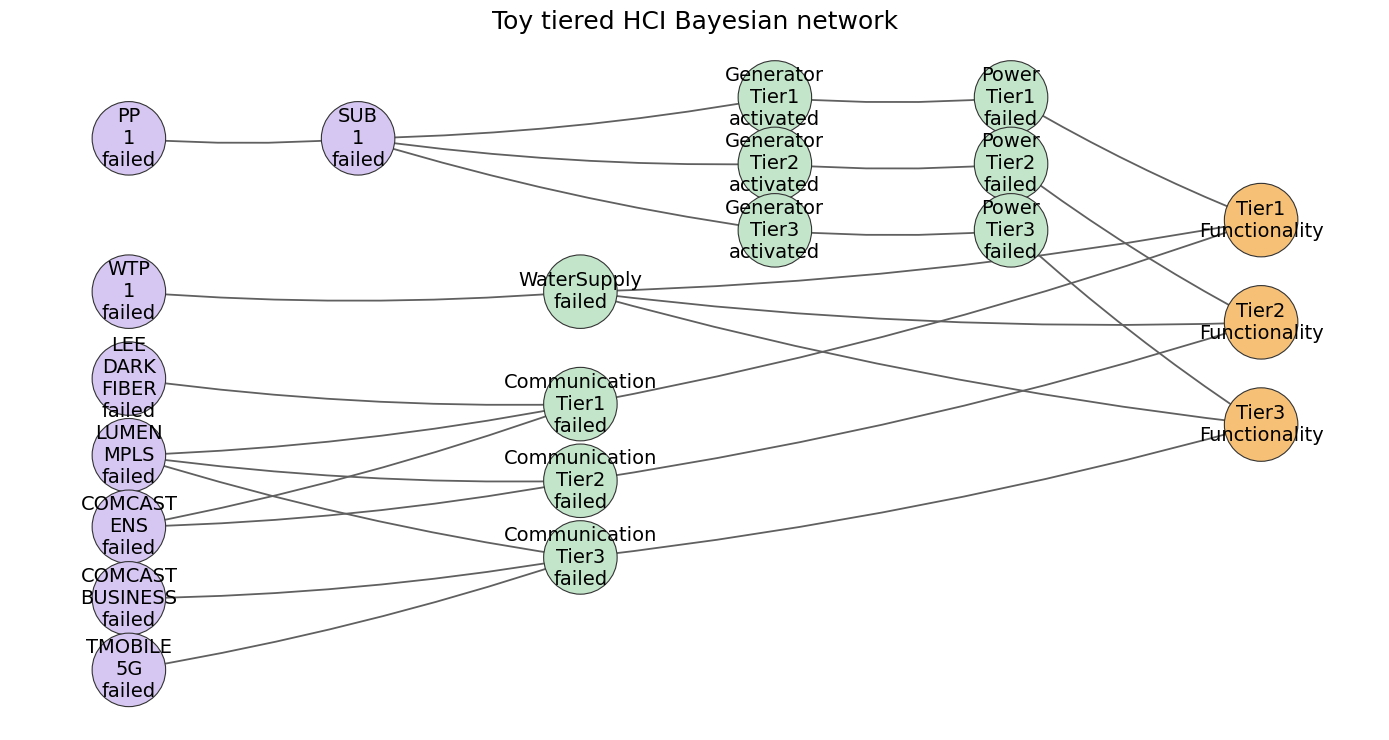

In [5]:
network_edges = dependency_edges[["parent", "child"]].itertuples(index=False, name=None)
G = nx.DiGraph()
G.add_edges_from(network_edges)

pos = {
    "PP_1_failed": (0.5, 3.35),
    "SUB_1_failed": (2.15, 3.35),
    "Generator_Tier1_activated": (5.15, 3.75),
    "Generator_Tier2_activated": (5.15, 3.1),
    "Generator_Tier3_activated": (5.15, 2.45),
    "Power_Tier1_failed": (6.85, 3.75),
    "Power_Tier2_failed": (6.85, 3.1),
    "Power_Tier3_failed": (6.85, 2.45),
    "WTP_1_failed": (0.5, 1.85),
    "WaterSupply_failed": (3.75, 1.85),
    "LEE_DARK_FIBER_failed": (0.5, 1.0),
    "LUMEN_MPLS_failed": (0.5, 0.25),
    "COMCAST_ENS_failed": (0.5, -0.45),
    "COMCAST_BUSINESS_failed": (0.5, -1.15),
    "TMOBILE_5G_failed": (0.5, -1.85),
    "Communication_Tier1_failed": (3.75, 0.75),
    "Communication_Tier2_failed": (3.75, 0.0),
    "Communication_Tier3_failed": (3.75, -0.75),
    "Tier1_Functionality": (8.65, 2.55),
    "Tier2_Functionality": (8.65, 1.55),
    "Tier3_Functionality": (8.65, 0.55),
}

node_colors = []
for node in G.nodes:
    if node.endswith("Functionality"):
        node_colors.append("#f6c177")
    elif "Generator" in node or "Tier" in node or "WaterSupply" in node:
        node_colors.append("#c3e6cb")
    else:
        node_colors.append("#d6c7f2")

plt.figure(figsize=(14, 7.5))
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="-|>", arrowsize=15, width=1.3, edge_color="#606060", connectionstyle="arc3,rad=0.04")
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2800, edgecolors="#333333", linewidths=0.8)
nx.draw_networkx_labels(G, pos, labels={n: n.replace("_", "\n") for n in G.nodes}, font_size=14)
plt.title("Toy tiered HCI Bayesian network", fontsize=18)
plt.axis("off")
plt.tight_layout()
plt.show()

## 1.2 Hurricane Ian flood depth and routine failure logs

Routine failure probabilities would be estimated from normal-condition outage logs, for example:

$$
P_\text{routine}(X=1)=\frac{\text{normal-condition failed hours}}{\text{normal-condition observed hours}}
$$

The toy values below stand in for that log-derived calculation.

In [6]:
flood_depth_t0 = pd.DataFrame([
    {"scenario_id": "HurricaneIan48h", "time_step": 0, "node_id": "PP_1", "flood_depth_m": 0.70, "source": "hydrodynamic_model"},
    {"scenario_id": "HurricaneIan48h", "time_step": 0, "node_id": "SUB_1", "flood_depth_m": 1.50, "source": "hydrodynamic_model"},
    {"scenario_id": "HurricaneIan48h", "time_step": 0, "node_id": "WTP_1", "flood_depth_m": 1.20, "source": "hydrodynamic_model"},
    {"scenario_id": "HurricaneIan48h", "time_step": 0, "node_id": "LEE_DARK_FIBER", "flood_depth_m": 0.60, "source": "hydrodynamic_model"},
    {"scenario_id": "HurricaneIan48h", "time_step": 0, "node_id": "LUMEN_MPLS", "flood_depth_m": 1.10, "source": "hydrodynamic_model"},
    {"scenario_id": "HurricaneIan48h", "time_step": 0, "node_id": "COMCAST_ENS", "flood_depth_m": 1.30, "source": "hydrodynamic_model"},
    {"scenario_id": "HurricaneIan48h", "time_step": 0, "node_id": "COMCAST_BUSINESS", "flood_depth_m": 1.80, "source": "hydrodynamic_model"},
    {"scenario_id": "HurricaneIan48h", "time_step": 0, "node_id": "TMOBILE_5G", "flood_depth_m": 0.80, "source": "hydrodynamic_model"},
])

routine_failure_logs = pd.DataFrame([
    {"variable": "PP_1_failed", "observed_hours": 8760, "failed_hours": 8, "routine_p_failed": 8 / 8760, "source": "normal-condition utility log"},
    {"variable": "SUB_1_failed", "observed_hours": 8760, "failed_hours": 14, "routine_p_failed": 14 / 8760, "source": "normal-condition utility log"},
    {"variable": "WTP_1_failed", "observed_hours": 8760, "failed_hours": 10, "routine_p_failed": 10 / 8760, "source": "normal-condition water utility log"},
    {"variable": "LEE_DARK_FIBER_failed", "observed_hours": 8760, "failed_hours": 6, "routine_p_failed": 6 / 8760, "source": "normal-condition telecom log"},
    {"variable": "LUMEN_MPLS_failed", "observed_hours": 8760, "failed_hours": 18, "routine_p_failed": 18 / 8760, "source": "normal-condition telecom log"},
    {"variable": "COMCAST_ENS_failed", "observed_hours": 8760, "failed_hours": 20, "routine_p_failed": 20 / 8760, "source": "normal-condition telecom log"},
    {"variable": "COMCAST_BUSINESS_failed", "observed_hours": 8760, "failed_hours": 26, "routine_p_failed": 26 / 8760, "source": "normal-condition telecom log"},
    {"variable": "TMOBILE_5G_failed", "observed_hours": 8760, "failed_hours": 16, "routine_p_failed": 16 / 8760, "source": "normal-condition telecom log"},
    {"variable": "WaterSupply_failed", "observed_hours": 8760, "failed_hours": 10, "routine_p_failed": 10 / 8760, "source": "normal-condition water utility log"},
    {"variable": "Communication_Tier1_failed", "observed_hours": 8760, "failed_hours": 5, "routine_p_failed": 5 / 8760, "source": "normal-condition network log"},
    {"variable": "Communication_Tier2_failed", "observed_hours": 8760, "failed_hours": 8, "routine_p_failed": 8 / 8760, "source": "normal-condition network log"},
    {"variable": "Communication_Tier3_failed", "observed_hours": 8760, "failed_hours": 15, "routine_p_failed": 15 / 8760, "source": "normal-condition network log"},
    {"variable": "Power_Tier1_failed", "observed_hours": 8760, "failed_hours": 4, "routine_p_failed": 4 / 8760, "source": "normal-condition facility log"},
    {"variable": "Power_Tier2_failed", "observed_hours": 8760, "failed_hours": 5, "routine_p_failed": 5 / 8760, "source": "normal-condition facility log"},
    {"variable": "Power_Tier3_failed", "observed_hours": 8760, "failed_hours": 7, "routine_p_failed": 7 / 8760, "source": "normal-condition facility log"},
])

tier_routine_functionality_logs = pd.DataFrame([
    {"tier_node": "Tier1_Functionality", "threshold": "ge_reduced", "routine_probability": 0.020, "source": "normal-condition facility status logs"},
    {"tier_node": "Tier1_Functionality", "threshold": "ge_critical", "routine_probability": 0.006, "source": "normal-condition facility status logs"},
    {"tier_node": "Tier1_Functionality", "threshold": "ge_failed", "routine_probability": 0.001, "source": "normal-condition facility status logs"},
    {"tier_node": "Tier2_Functionality", "threshold": "ge_reduced", "routine_probability": 0.025, "source": "normal-condition facility status logs"},
    {"tier_node": "Tier2_Functionality", "threshold": "ge_critical", "routine_probability": 0.007, "source": "normal-condition facility status logs"},
    {"tier_node": "Tier2_Functionality", "threshold": "ge_failed", "routine_probability": 0.0015, "source": "normal-condition facility status logs"},
    {"tier_node": "Tier3_Functionality", "threshold": "ge_reduced", "routine_probability": 0.030, "source": "normal-condition facility status logs"},
    {"tier_node": "Tier3_Functionality", "threshold": "ge_critical", "routine_probability": 0.008, "source": "normal-condition facility status logs"},
    {"tier_node": "Tier3_Functionality", "threshold": "ge_failed", "routine_probability": 0.002, "source": "normal-condition facility status logs"},
])

display(flood_depth_t0)
display(routine_failure_logs)
display(tier_routine_functionality_logs)

,scenario_id,time_step,node_id,flood_depth_m,source
0,HurricaneIan48h,0,PP_1,0.7,hydrodynamic_model
1,HurricaneIan48h,0,SUB_1,1.5,hydrodynamic_model
2,HurricaneIan48h,0,WTP_1,1.2,hydrodynamic_model
3,HurricaneIan48h,0,LEE_DARK_FIBER,0.6,hydrodynamic_model
4,HurricaneIan48h,0,LUMEN_MPLS,1.1,hydrodynamic_model
5,HurricaneIan48h,0,COMCAST_ENS,1.3,hydrodynamic_model
6,HurricaneIan48h,0,COMCAST_BUSINESS,1.8,hydrodynamic_model
7,HurricaneIan48h,0,TMOBILE_5G,0.8,hydrodynamic_model


,variable,observed_hours,failed_hours,routine_p_failed,source
0,PP_1_failed,8760,8,0.000913,normal-condition utility log
1,SUB_1_failed,8760,14,0.001598,normal-condition utility log
2,WTP_1_failed,8760,10,0.001142,normal-condition water utility log
3,LEE_DARK_FIBER_failed,8760,6,0.000685,normal-condition telecom log
4,LUMEN_MPLS_failed,8760,18,0.002055,normal-condition telecom log
5,COMCAST_ENS_failed,8760,20,0.002283,normal-condition telecom log
6,COMCAST_BUSINESS_failed,8760,26,0.002968,normal-condition telecom log
7,TMOBILE_5G_failed,8760,16,0.001826,normal-condition telecom log
8,WaterSupply_failed,8760,10,0.001142,normal-condition water utility log
9,Communication_Tier1_failed,8760,5,0.000571,normal-condition network log


,tier_node,threshold,routine_probability,source
0,Tier1_Functionality,ge_reduced,0.0200,normal-condition facility status logs
1,Tier1_Functionality,ge_critical,0.0060,normal-condition facility status logs
2,Tier1_Functionality,ge_failed,0.0010,normal-condition facility status logs
3,Tier2_Functionality,ge_reduced,0.0250,normal-condition facility status logs
4,Tier2_Functionality,ge_critical,0.0070,normal-condition facility status logs
5,Tier2_Functionality,ge_failed,0.0015,normal-condition facility status logs
6,Tier3_Functionality,ge_reduced,0.0300,normal-condition facility status logs
7,Tier3_Functionality,ge_critical,0.0080,normal-condition facility status logs
8,Tier3_Functionality,ge_failed,0.0020,normal-condition facility status logs


## 2. Expert-elicited CPT construction with fuzzy probability levels

Experts are only asked about dependency strengths. Routine failure probabilities are estimated
from logs and are not included in the expert-elicited CPT questions.

The elicitation follows a simple fuzzy-probability workflow: ask a structured question, collect a
linguistic probability level from each expert, map the linguistic levels to triangular fuzzy
numbers, average the fuzzy numbers across experts, and defuzzify the aggregate with the centroid
method.

### Expert elicitation questionnaire

The questions below are generated from the same `expert_elicitation_questions` dataframe used by the fuzzy-number workflow. Experts answer each item with one linguistic probability level from the fuzzy scale.

Each main dependency chain is elicited independently. For example, the water questions ask only about the consequence of water unavailability for a tier; they do not assume the power or communication chains are available. The same independent-chain logic is used for power and communication.

- `Tier1_Functionality|PowerChain_with_generator|Normal`: If the power chain is unavailable for Tier 1 and the Tier 1 generator is activated within its five-day runtime window, what is the probability that Tier 1 functionality is Normal?
- `Tier1_Functionality|PowerChain_with_generator|Reduced`: If the power chain is unavailable for Tier 1 and the Tier 1 generator is activated within its five-day runtime window, what is the probability that Tier 1 functionality is Reduced?
- `Tier1_Functionality|PowerChain_with_generator|Critical`: If the power chain is unavailable for Tier 1 and the Tier 1 generator is activated within its five-day runtime window, what is the probability that Tier 1 functionality is Critical?
- `Tier1_Functionality|PowerChain_with_generator|Failed`: If the power chain is unavailable for Tier 1 and the Tier 1 generator is activated within its five-day runtime window, what is the probability that Tier 1 functionality is Failed?
- `Tier1_Functionality|WaterSupply_failed|Normal`: If water service is unavailable for Tier 1, what is the probability that Tier 1 functionality is Normal?
- `Tier1_Functionality|WaterSupply_failed|Reduced`: If water service is unavailable for Tier 1, what is the probability that Tier 1 functionality is Reduced?
- `Tier1_Functionality|WaterSupply_failed|Critical`: If water service is unavailable for Tier 1, what is the probability that Tier 1 functionality is Critical?
- `Tier1_Functionality|WaterSupply_failed|Failed`: If water service is unavailable for Tier 1, what is the probability that Tier 1 functionality is Failed?
- `Tier1_Functionality|Communication_failed|Normal`: If communications are unavailable for Tier 1, what is the probability that Tier 1 functionality is Normal?
- `Tier1_Functionality|Communication_failed|Reduced`: If communications are unavailable for Tier 1, what is the probability that Tier 1 functionality is Reduced?
- `Tier1_Functionality|Communication_failed|Critical`: If communications are unavailable for Tier 1, what is the probability that Tier 1 functionality is Critical?
- `Tier1_Functionality|Communication_failed|Failed`: If communications are unavailable for Tier 1, what is the probability that Tier 1 functionality is Failed?
- `Tier2_Functionality|PowerChain_with_generator|Normal`: If the power chain is unavailable for Tier 2 and the Tier 2 generator is activated within its five-day runtime window, what is the probability that Tier 2 functionality is Normal?
- `Tier2_Functionality|PowerChain_with_generator|Reduced`: If the power chain is unavailable for Tier 2 and the Tier 2 generator is activated within its five-day runtime window, what is the probability that Tier 2 functionality is Reduced?
- `Tier2_Functionality|PowerChain_with_generator|Critical`: If the power chain is unavailable for Tier 2 and the Tier 2 generator is activated within its five-day runtime window, what is the probability that Tier 2 functionality is Critical?
- `Tier2_Functionality|PowerChain_with_generator|Failed`: If the power chain is unavailable for Tier 2 and the Tier 2 generator is activated within its five-day runtime window, what is the probability that Tier 2 functionality is Failed?
- `Tier2_Functionality|WaterSupply_failed|Normal`: If water service is unavailable for Tier 2, what is the probability that Tier 2 functionality is Normal?
- `Tier2_Functionality|WaterSupply_failed|Reduced`: If water service is unavailable for Tier 2, what is the probability that Tier 2 functionality is Reduced?
- `Tier2_Functionality|WaterSupply_failed|Critical`: If water service is unavailable for Tier 2, what is the probability that Tier 2 functionality is Critical?
- `Tier2_Functionality|WaterSupply_failed|Failed`: If water service is unavailable for Tier 2, what is the probability that Tier 2 functionality is Failed?
- `Tier2_Functionality|Communication_failed|Normal`: If communications are unavailable for Tier 2, what is the probability that Tier 2 functionality is Normal?
- `Tier2_Functionality|Communication_failed|Reduced`: If communications are unavailable for Tier 2, what is the probability that Tier 2 functionality is Reduced?
- `Tier2_Functionality|Communication_failed|Critical`: If communications are unavailable for Tier 2, what is the probability that Tier 2 functionality is Critical?
- `Tier2_Functionality|Communication_failed|Failed`: If communications are unavailable for Tier 2, what is the probability that Tier 2 functionality is Failed?
- `Tier3_Functionality|PowerChain_with_generator|Normal`: If the power chain is unavailable for Tier 3 and the Tier 3 generator is activated within its five-day runtime window, what is the probability that Tier 3 functionality is Normal?
- `Tier3_Functionality|PowerChain_with_generator|Reduced`: If the power chain is unavailable for Tier 3 and the Tier 3 generator is activated within its five-day runtime window, what is the probability that Tier 3 functionality is Reduced?
- `Tier3_Functionality|PowerChain_with_generator|Critical`: If the power chain is unavailable for Tier 3 and the Tier 3 generator is activated within its five-day runtime window, what is the probability that Tier 3 functionality is Critical?
- `Tier3_Functionality|PowerChain_with_generator|Failed`: If the power chain is unavailable for Tier 3 and the Tier 3 generator is activated within its five-day runtime window, what is the probability that Tier 3 functionality is Failed?
- `Tier3_Functionality|WaterSupply_failed|Normal`: If water service is unavailable for Tier 3, what is the probability that Tier 3 functionality is Normal?
- `Tier3_Functionality|WaterSupply_failed|Reduced`: If water service is unavailable for Tier 3, what is the probability that Tier 3 functionality is Reduced?
- `Tier3_Functionality|WaterSupply_failed|Critical`: If water service is unavailable for Tier 3, what is the probability that Tier 3 functionality is Critical?
- `Tier3_Functionality|WaterSupply_failed|Failed`: If water service is unavailable for Tier 3, what is the probability that Tier 3 functionality is Failed?
- `Tier3_Functionality|Communication_failed|Normal`: If communications are unavailable for Tier 3, what is the probability that Tier 3 functionality is Normal?
- `Tier3_Functionality|Communication_failed|Reduced`: If communications are unavailable for Tier 3, what is the probability that Tier 3 functionality is Reduced?
- `Tier3_Functionality|Communication_failed|Critical`: If communications are unavailable for Tier 3, what is the probability that Tier 3 functionality is Critical?
- `Tier3_Functionality|Communication_failed|Failed`: If communications are unavailable for Tier 3, what is the probability that Tier 3 functionality is Failed?

In [7]:
expert_elicitation_questions = pd.DataFrame([{'parameter_id': 'Tier1_Functionality|PowerChain_with_generator|Normal', 'question': 'If the power chain is unavailable for Tier 1 and the Tier 1 generator is activated within its five-day runtime window, what is the probability that Tier 1 functionality is Normal?'}, {'parameter_id': 'Tier1_Functionality|PowerChain_with_generator|Reduced', 'question': 'If the power chain is unavailable for Tier 1 and the Tier 1 generator is activated within its five-day runtime window, what is the probability that Tier 1 functionality is Reduced?'}, {'parameter_id': 'Tier1_Functionality|PowerChain_with_generator|Critical', 'question': 'If the power chain is unavailable for Tier 1 and the Tier 1 generator is activated within its five-day runtime window, what is the probability that Tier 1 functionality is Critical?'}, {'parameter_id': 'Tier1_Functionality|PowerChain_with_generator|Failed', 'question': 'If the power chain is unavailable for Tier 1 and the Tier 1 generator is activated within its five-day runtime window, what is the probability that Tier 1 functionality is Failed?'}, {'parameter_id': 'Tier1_Functionality|WaterSupply_failed|Normal', 'question': 'If water service is unavailable for Tier 1, what is the probability that Tier 1 functionality is Normal?'}, {'parameter_id': 'Tier1_Functionality|WaterSupply_failed|Reduced', 'question': 'If water service is unavailable for Tier 1, what is the probability that Tier 1 functionality is Reduced?'}, {'parameter_id': 'Tier1_Functionality|WaterSupply_failed|Critical', 'question': 'If water service is unavailable for Tier 1, what is the probability that Tier 1 functionality is Critical?'}, {'parameter_id': 'Tier1_Functionality|WaterSupply_failed|Failed', 'question': 'If water service is unavailable for Tier 1, what is the probability that Tier 1 functionality is Failed?'}, {'parameter_id': 'Tier1_Functionality|Communication_failed|Normal', 'question': 'If communications are unavailable for Tier 1, what is the probability that Tier 1 functionality is Normal?'}, {'parameter_id': 'Tier1_Functionality|Communication_failed|Reduced', 'question': 'If communications are unavailable for Tier 1, what is the probability that Tier 1 functionality is Reduced?'}, {'parameter_id': 'Tier1_Functionality|Communication_failed|Critical', 'question': 'If communications are unavailable for Tier 1, what is the probability that Tier 1 functionality is Critical?'}, {'parameter_id': 'Tier1_Functionality|Communication_failed|Failed', 'question': 'If communications are unavailable for Tier 1, what is the probability that Tier 1 functionality is Failed?'}, {'parameter_id': 'Tier2_Functionality|PowerChain_with_generator|Normal', 'question': 'If the power chain is unavailable for Tier 2 and the Tier 2 generator is activated within its five-day runtime window, what is the probability that Tier 2 functionality is Normal?'}, {'parameter_id': 'Tier2_Functionality|PowerChain_with_generator|Reduced', 'question': 'If the power chain is unavailable for Tier 2 and the Tier 2 generator is activated within its five-day runtime window, what is the probability that Tier 2 functionality is Reduced?'}, {'parameter_id': 'Tier2_Functionality|PowerChain_with_generator|Critical', 'question': 'If the power chain is unavailable for Tier 2 and the Tier 2 generator is activated within its five-day runtime window, what is the probability that Tier 2 functionality is Critical?'}, {'parameter_id': 'Tier2_Functionality|PowerChain_with_generator|Failed', 'question': 'If the power chain is unavailable for Tier 2 and the Tier 2 generator is activated within its five-day runtime window, what is the probability that Tier 2 functionality is Failed?'}, {'parameter_id': 'Tier2_Functionality|WaterSupply_failed|Normal', 'question': 'If water service is unavailable for Tier 2, what is the probability that Tier 2 functionality is Normal?'}, {'parameter_id': 'Tier2_Functionality|WaterSupply_failed|Reduced', 'question': 'If water service is unavailable for Tier 2, what is the probability that Tier 2 functionality is Reduced?'}, {'parameter_id': 'Tier2_Functionality|WaterSupply_failed|Critical', 'question': 'If water service is unavailable for Tier 2, what is the probability that Tier 2 functionality is Critical?'}, {'parameter_id': 'Tier2_Functionality|WaterSupply_failed|Failed', 'question': 'If water service is unavailable for Tier 2, what is the probability that Tier 2 functionality is Failed?'}, {'parameter_id': 'Tier2_Functionality|Communication_failed|Normal', 'question': 'If communications are unavailable for Tier 2, what is the probability that Tier 2 functionality is Normal?'}, {'parameter_id': 'Tier2_Functionality|Communication_failed|Reduced', 'question': 'If communications are unavailable for Tier 2, what is the probability that Tier 2 functionality is Reduced?'}, {'parameter_id': 'Tier2_Functionality|Communication_failed|Critical', 'question': 'If communications are unavailable for Tier 2, what is the probability that Tier 2 functionality is Critical?'}, {'parameter_id': 'Tier2_Functionality|Communication_failed|Failed', 'question': 'If communications are unavailable for Tier 2, what is the probability that Tier 2 functionality is Failed?'}, {'parameter_id': 'Tier3_Functionality|PowerChain_with_generator|Normal', 'question': 'If the power chain is unavailable for Tier 3 and the Tier 3 generator is activated within its five-day runtime window, what is the probability that Tier 3 functionality is Normal?'}, {'parameter_id': 'Tier3_Functionality|PowerChain_with_generator|Reduced', 'question': 'If the power chain is unavailable for Tier 3 and the Tier 3 generator is activated within its five-day runtime window, what is the probability that Tier 3 functionality is Reduced?'}, {'parameter_id': 'Tier3_Functionality|PowerChain_with_generator|Critical', 'question': 'If the power chain is unavailable for Tier 3 and the Tier 3 generator is activated within its five-day runtime window, what is the probability that Tier 3 functionality is Critical?'}, {'parameter_id': 'Tier3_Functionality|PowerChain_with_generator|Failed', 'question': 'If the power chain is unavailable for Tier 3 and the Tier 3 generator is activated within its five-day runtime window, what is the probability that Tier 3 functionality is Failed?'}, {'parameter_id': 'Tier3_Functionality|WaterSupply_failed|Normal', 'question': 'If water service is unavailable for Tier 3, what is the probability that Tier 3 functionality is Normal?'}, {'parameter_id': 'Tier3_Functionality|WaterSupply_failed|Reduced', 'question': 'If water service is unavailable for Tier 3, what is the probability that Tier 3 functionality is Reduced?'}, {'parameter_id': 'Tier3_Functionality|WaterSupply_failed|Critical', 'question': 'If water service is unavailable for Tier 3, what is the probability that Tier 3 functionality is Critical?'}, {'parameter_id': 'Tier3_Functionality|WaterSupply_failed|Failed', 'question': 'If water service is unavailable for Tier 3, what is the probability that Tier 3 functionality is Failed?'}, {'parameter_id': 'Tier3_Functionality|Communication_failed|Normal', 'question': 'If communications are unavailable for Tier 3, what is the probability that Tier 3 functionality is Normal?'}, {'parameter_id': 'Tier3_Functionality|Communication_failed|Reduced', 'question': 'If communications are unavailable for Tier 3, what is the probability that Tier 3 functionality is Reduced?'}, {'parameter_id': 'Tier3_Functionality|Communication_failed|Critical', 'question': 'If communications are unavailable for Tier 3, what is the probability that Tier 3 functionality is Critical?'}, {'parameter_id': 'Tier3_Functionality|Communication_failed|Failed', 'question': 'If communications are unavailable for Tier 3, what is the probability that Tier 3 functionality is Failed?'}])

expert_elicitation_questions

,parameter_id,question
0,Tier1_Functionality|PowerChain_with_generator|...,If the power chain is unavailable for Tier 1 a...
1,Tier1_Functionality|PowerChain_with_generator|...,If the power chain is unavailable for Tier 1 a...
2,Tier1_Functionality|PowerChain_with_generator|...,If the power chain is unavailable for Tier 1 a...
3,Tier1_Functionality|PowerChain_with_generator|...,If the power chain is unavailable for Tier 1 a...
4,Tier1_Functionality|WaterSupply_failed|Normal,"If water service is unavailable for Tier 1, wh..."
5,Tier1_Functionality|WaterSupply_failed|Reduced,"If water service is unavailable for Tier 1, wh..."
6,Tier1_Functionality|WaterSupply_failed|Critical,"If water service is unavailable for Tier 1, wh..."
7,Tier1_Functionality|WaterSupply_failed|Failed,"If water service is unavailable for Tier 1, wh..."
8,Tier1_Functionality|Communication_failed|Normal,"If communications are unavailable for Tier 1, ..."
9,Tier1_Functionality|Communication_failed|Reduced,"If communications are unavailable for Tier 1, ..."


In [8]:
fuzzy_probability_scale = pd.DataFrame([
    {"linguistic_level": "Rare", "lower": 0.000, "mode": 0.005, "upper": 0.020},
    {"linguistic_level": "Very Low", "lower": 0.005, "mode": 0.020, "upper": 0.060},
    {"linguistic_level": "Low", "lower": 0.040, "mode": 0.100, "upper": 0.200},
    {"linguistic_level": "Moderately Low", "lower": 0.150, "mode": 0.250, "upper": 0.400},
    {"linguistic_level": "Medium", "lower": 0.300, "mode": 0.450, "upper": 0.600},
    {"linguistic_level": "Moderately High", "lower": 0.500, "mode": 0.620, "upper": 0.750},
    {"linguistic_level": "High", "lower": 0.650, "mode": 0.780, "upper": 0.900},
    {"linguistic_level": "Very High", "lower": 0.800, "mode": 0.920, "upper": 1.000},
])
fuzzy_probability_scale["centroid_probability"] = fuzzy_probability_scale[["lower", "mode", "upper"]].mean(axis=1)
fuzzy_probability_scale

,linguistic_level,lower,mode,upper,centroid_probability
0,Rare,0.000,0.005,0.02,0.008333
1,Very Low,0.005,0.020,0.06,0.028333
2,Low,0.040,0.100,0.20,0.113333
3,Moderately Low,0.150,0.250,0.40,0.266667
4,Medium,0.300,0.450,0.60,0.450000
5,Moderately High,0.500,0.620,0.75,0.623333
6,High,0.650,0.780,0.90,0.776667
7,Very High,0.800,0.920,1.00,0.906667


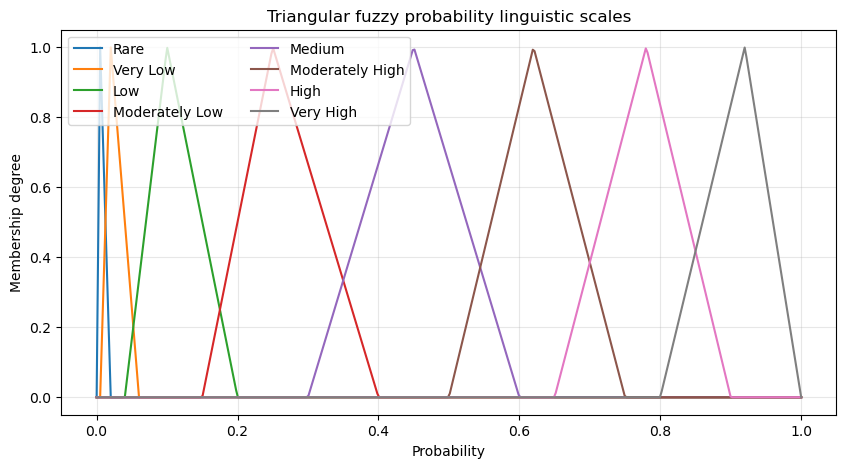

In [9]:
x = np.linspace(0, 1, 400)
plt.figure(figsize=(10, 5))
for _, row in fuzzy_probability_scale.iterrows():
    l, m, u = row["lower"], row["mode"], row["upper"]
    membership = np.zeros_like(x)
    left = (x >= l) & (x <= m)
    right = (x >= m) & (x <= u)
    if m > l:
        membership[left] = (x[left] - l) / (m - l)
    membership[x == m] = 1.0
    if u > m:
        membership[right] = (u - x[right]) / (u - m)
    plt.plot(x, membership, label=row["linguistic_level"])

plt.xlabel("Probability")
plt.ylabel("Membership degree")
plt.title("Triangular fuzzy probability linguistic scales")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
expert_rating_inputs = pd.DataFrame([{'parameter_id': 'Tier1_Functionality|PowerChain_with_generator|Normal', 'expert_1': 'Medium', 'expert_2': 'Moderately High', 'expert_3': 'Medium'}, {'parameter_id': 'Tier1_Functionality|PowerChain_with_generator|Reduced', 'expert_1': 'Moderately Low', 'expert_2': 'Low', 'expert_3': 'Moderately Low'}, {'parameter_id': 'Tier1_Functionality|PowerChain_with_generator|Critical', 'expert_1': 'Very Low', 'expert_2': 'Low', 'expert_3': 'Very Low'}, {'parameter_id': 'Tier1_Functionality|PowerChain_with_generator|Failed', 'expert_1': 'Rare', 'expert_2': 'Very Low', 'expert_3': 'Rare'}, {'parameter_id': 'Tier2_Functionality|PowerChain_with_generator|Normal', 'expert_1': 'Medium', 'expert_2': 'Medium', 'expert_3': 'Moderately High'}, {'parameter_id': 'Tier2_Functionality|PowerChain_with_generator|Reduced', 'expert_1': 'Moderately Low', 'expert_2': 'Moderately Low', 'expert_3': 'Low'}, {'parameter_id': 'Tier2_Functionality|PowerChain_with_generator|Critical', 'expert_1': 'Very Low', 'expert_2': 'Low', 'expert_3': 'Very Low'}, {'parameter_id': 'Tier2_Functionality|PowerChain_with_generator|Failed', 'expert_1': 'Rare', 'expert_2': 'Rare', 'expert_3': 'Very Low'}, {'parameter_id': 'Tier3_Functionality|PowerChain_with_generator|Normal', 'expert_1': 'Medium', 'expert_2': 'Medium', 'expert_3': 'Medium'}, {'parameter_id': 'Tier3_Functionality|PowerChain_with_generator|Reduced', 'expert_1': 'Moderately Low', 'expert_2': 'Moderately Low', 'expert_3': 'Low'}, {'parameter_id': 'Tier3_Functionality|PowerChain_with_generator|Critical', 'expert_1': 'Low', 'expert_2': 'Very Low', 'expert_3': 'Low'}, {'parameter_id': 'Tier3_Functionality|PowerChain_with_generator|Failed', 'expert_1': 'Rare', 'expert_2': 'Very Low', 'expert_3': 'Rare'}, {'parameter_id': 'Tier1_Functionality|WaterSupply_failed|Normal', 'expert_1': 'Very Low', 'expert_2': 'Low', 'expert_3': 'Very Low'}, {'parameter_id': 'Tier1_Functionality|WaterSupply_failed|Reduced', 'expert_1': 'Moderately Low', 'expert_2': 'Medium', 'expert_3': 'Moderately Low'}, {'parameter_id': 'Tier1_Functionality|WaterSupply_failed|Critical', 'expert_1': 'Medium', 'expert_2': 'Moderately Low', 'expert_3': 'Medium'}, {'parameter_id': 'Tier1_Functionality|WaterSupply_failed|Failed', 'expert_1': 'Low', 'expert_2': 'Moderately Low', 'expert_3': 'Low'}, {'parameter_id': 'Tier2_Functionality|WaterSupply_failed|Normal', 'expert_1': 'Low', 'expert_2': 'Low', 'expert_3': 'Very Low'}, {'parameter_id': 'Tier2_Functionality|WaterSupply_failed|Reduced', 'expert_1': 'Medium', 'expert_2': 'Moderately Low', 'expert_3': 'Medium'}, {'parameter_id': 'Tier2_Functionality|WaterSupply_failed|Critical', 'expert_1': 'Moderately Low', 'expert_2': 'Medium', 'expert_3': 'Moderately Low'}, {'parameter_id': 'Tier2_Functionality|WaterSupply_failed|Failed', 'expert_1': 'Low', 'expert_2': 'Low', 'expert_3': 'Very Low'}, {'parameter_id': 'Tier3_Functionality|WaterSupply_failed|Normal', 'expert_1': 'Low', 'expert_2': 'Moderately Low', 'expert_3': 'Low'}, {'parameter_id': 'Tier3_Functionality|WaterSupply_failed|Reduced', 'expert_1': 'Medium', 'expert_2': 'Moderately Low', 'expert_3': 'Medium'}, {'parameter_id': 'Tier3_Functionality|WaterSupply_failed|Critical', 'expert_1': 'Moderately Low', 'expert_2': 'Low', 'expert_3': 'Moderately Low'}, {'parameter_id': 'Tier3_Functionality|WaterSupply_failed|Failed', 'expert_1': 'Very Low', 'expert_2': 'Low', 'expert_3': 'Very Low'}, {'parameter_id': 'Tier1_Functionality|Communication_failed|Normal', 'expert_1': 'Low', 'expert_2': 'Moderately Low', 'expert_3': 'Low'}, {'parameter_id': 'Tier1_Functionality|Communication_failed|Reduced', 'expert_1': 'Medium', 'expert_2': 'Moderately Low', 'expert_3': 'Medium'}, {'parameter_id': 'Tier1_Functionality|Communication_failed|Critical', 'expert_1': 'Low', 'expert_2': 'Moderately Low', 'expert_3': 'Low'}, {'parameter_id': 'Tier1_Functionality|Communication_failed|Failed', 'expert_1': 'Very Low', 'expert_2': 'Low', 'expert_3': 'Very Low'}, {'parameter_id': 'Tier2_Functionality|Communication_failed|Normal', 'expert_1': 'Low', 'expert_2': 'Moderately Low', 'expert_3': 'Low'}, {'parameter_id': 'Tier2_Functionality|Communication_failed|Reduced', 'expert_1': 'Medium', 'expert_2': 'Medium', 'expert_3': 'Moderately Low'}, {'parameter_id': 'Tier2_Functionality|Communication_failed|Critical', 'expert_1': 'Moderately Low', 'expert_2': 'Low', 'expert_3': 'Moderately Low'}, {'parameter_id': 'Tier2_Functionality|Communication_failed|Failed', 'expert_1': 'Very Low', 'expert_2': 'Low', 'expert_3': 'Very Low'}, {'parameter_id': 'Tier3_Functionality|Communication_failed|Normal', 'expert_1': 'Moderately Low', 'expert_2': 'Low', 'expert_3': 'Moderately Low'}, {'parameter_id': 'Tier3_Functionality|Communication_failed|Reduced', 'expert_1': 'Medium', 'expert_2': 'Moderately Low', 'expert_3': 'Medium'}, {'parameter_id': 'Tier3_Functionality|Communication_failed|Critical', 'expert_1': 'Low', 'expert_2': 'Moderately Low', 'expert_3': 'Low'}, {'parameter_id': 'Tier3_Functionality|Communication_failed|Failed', 'expert_1': 'Very Low', 'expert_2': 'Low', 'expert_3': 'Low'}])
expert_rating_inputs = expert_rating_inputs.merge(expert_elicitation_questions, on="parameter_id", how="left")

def aggregate_fuzzy_expert_ratings(rating_df, scale_df):
    scale = scale_df.set_index("linguistic_level")[["lower", "mode", "upper"]]
    records = []
    for _, row in rating_df.iterrows():
        triples = scale.loc[[row["expert_1"], row["expert_2"], row["expert_3"]]].to_numpy(dtype=float)
        avg_lower, avg_mode, avg_upper = triples.mean(axis=0)
        records.append({
            "parameter_id": row["parameter_id"],
            "question": row["question"],
            "expert_1": row["expert_1"],
            "expert_2": row["expert_2"],
            "expert_3": row["expert_3"],
            "fuzzy_lower": avg_lower,
            "fuzzy_mode": avg_mode,
            "fuzzy_upper": avg_upper,
            "defuzzified_score": (avg_lower + avg_mode + avg_upper) / 3.0,
        })
    return pd.DataFrame(records)

elicited_probability_table = aggregate_fuzzy_expert_ratings(expert_rating_inputs, fuzzy_probability_scale)

parsed = elicited_probability_table["parameter_id"].str.split("|", expand=True)
elicited_probability_table["tier_node"] = parsed[0]
elicited_probability_table["failure_chain"] = parsed[1]
elicited_probability_table["state"] = parsed[2]
state_score_totals = elicited_probability_table.groupby(["tier_node", "failure_chain"])["defuzzified_score"].transform("sum")
elicited_probability_table["state_probability"] = elicited_probability_table["defuzzified_score"] / state_score_totals

chain_state_probability = elicited_probability_table.pivot_table(
    index=["tier_node", "failure_chain"],
    columns="state",
    values="state_probability",
).reset_index()
chain_state_probability["ge_reduced"] = chain_state_probability[["Reduced", "Critical", "Failed"]].sum(axis=1)
chain_state_probability["ge_critical"] = chain_state_probability[["Critical", "Failed"]].sum(axis=1)
chain_state_probability["ge_failed"] = chain_state_probability["Failed"]

chain_to_parent = {
    "PowerChain_with_generator": {"Tier1": "Power_Tier1_failed", "Tier2": "Power_Tier2_failed", "Tier3": "Power_Tier3_failed"},
    "WaterSupply_failed": {"Tier1": "WaterSupply_failed", "Tier2": "WaterSupply_failed", "Tier3": "WaterSupply_failed"},
    "Communication_failed": {"Tier1": "Communication_Tier1_failed", "Tier2": "Communication_Tier2_failed", "Tier3": "Communication_Tier3_failed"},
}

elicited_probability_lookup = {}
for _, row in chain_state_probability.iterrows():
    tier = row["tier_node"].replace("_Functionality", "")
    parent = chain_to_parent[row["failure_chain"]][tier]
    for threshold in ["ge_reduced", "ge_critical", "ge_failed"]:
        elicited_probability_lookup[f"{row['tier_node']}|{threshold}|{parent}"] = float(row[threshold])

display(expert_rating_inputs)
display(elicited_probability_table)
display(chain_state_probability)

,parameter_id,expert_1,expert_2,expert_3,question
0,Tier1_Functionality|PowerChain_with_generator|...,Medium,Moderately High,Medium,If the power chain is unavailable for Tier 1 a...
1,Tier1_Functionality|PowerChain_with_generator|...,Moderately Low,Low,Moderately Low,If the power chain is unavailable for Tier 1 a...
2,Tier1_Functionality|PowerChain_with_generator|...,Very Low,Low,Very Low,If the power chain is unavailable for Tier 1 a...
3,Tier1_Functionality|PowerChain_with_generator|...,Rare,Very Low,Rare,If the power chain is unavailable for Tier 1 a...
4,Tier2_Functionality|PowerChain_with_generator|...,Medium,Medium,Moderately High,If the power chain is unavailable for Tier 2 a...
5,Tier2_Functionality|PowerChain_with_generator|...,Moderately Low,Moderately Low,Low,If the power chain is unavailable for Tier 2 a...
6,Tier2_Functionality|PowerChain_with_generator|...,Very Low,Low,Very Low,If the power chain is unavailable for Tier 2 a...
7,Tier2_Functionality|PowerChain_with_generator|...,Rare,Rare,Very Low,If the power chain is unavailable for Tier 2 a...
8,Tier3_Functionality|PowerChain_with_generator|...,Medium,Medium,Medium,If the power chain is unavailable for Tier 3 a...
9,Tier3_Functionality|PowerChain_with_generator|...,Moderately Low,Moderately Low,Low,If the power chain is unavailable for Tier 3 a...


,parameter_id,question,expert_1,expert_2,expert_3,fuzzy_lower,fuzzy_mode,fuzzy_upper,defuzzified_score,tier_node,failure_chain,state,state_probability
0,Tier1_Functionality|PowerChain_with_generator|...,If the power chain is unavailable for Tier 1 a...,Medium,Moderately High,Medium,0.366667,0.506667,0.650000,0.507778,Tier1_Functionality,PowerChain_with_generator,Normal,0.638714
1,Tier1_Functionality|PowerChain_with_generator|...,If the power chain is unavailable for Tier 1 a...,Moderately Low,Low,Moderately Low,0.113333,0.200000,0.333333,0.215556,Tier1_Functionality,PowerChain_with_generator,Reduced,0.271139
2,Tier1_Functionality|PowerChain_with_generator|...,If the power chain is unavailable for Tier 1 a...,Very Low,Low,Very Low,0.016667,0.046667,0.106667,0.056667,Tier1_Functionality,PowerChain_with_generator,Critical,0.071279
3,Tier1_Functionality|PowerChain_with_generator|...,If the power chain is unavailable for Tier 1 a...,Rare,Very Low,Rare,0.001667,0.010000,0.033333,0.015000,Tier1_Functionality,PowerChain_with_generator,Failed,0.018868
4,Tier2_Functionality|PowerChain_with_generator|...,If the power chain is unavailable for Tier 2 a...,Medium,Medium,Moderately High,0.366667,0.506667,0.650000,0.507778,Tier2_Functionality,PowerChain_with_generator,Normal,0.638714
5,Tier2_Functionality|PowerChain_with_generator|...,If the power chain is unavailable for Tier 2 a...,Moderately Low,Moderately Low,Low,0.113333,0.200000,0.333333,0.215556,Tier2_Functionality,PowerChain_with_generator,Reduced,0.271139
6,Tier2_Functionality|PowerChain_with_generator|...,If the power chain is unavailable for Tier 2 a...,Very Low,Low,Very Low,0.016667,0.046667,0.106667,0.056667,Tier2_Functionality,PowerChain_with_generator,Critical,0.071279
7,Tier2_Functionality|PowerChain_with_generator|...,If the power chain is unavailable for Tier 2 a...,Rare,Rare,Very Low,0.001667,0.010000,0.033333,0.015000,Tier2_Functionality,PowerChain_with_generator,Failed,0.018868
8,Tier3_Functionality|PowerChain_with_generator|...,If the power chain is unavailable for Tier 3 a...,Medium,Medium,Medium,0.300000,0.450000,0.600000,0.450000,Tier3_Functionality,PowerChain_with_generator,Normal,0.587808
9,Tier3_Functionality|PowerChain_with_generator|...,If the power chain is unavailable for Tier 3 a...,Moderately Low,Moderately Low,Low,0.113333,0.200000,0.333333,0.215556,Tier3_Functionality,PowerChain_with_generator,Reduced,0.281567


state,tier_node,failure_chain,Critical,Failed,Normal,Reduced,ge_reduced,ge_critical,ge_failed
0,Tier1_Functionality,Communication_failed,0.212339,0.073171,0.212339,0.502152,0.787661,0.285509,0.073171
1,Tier1_Functionality,PowerChain_with_generator,0.071279,0.018868,0.638714,0.271139,0.361286,0.090147,0.018868
2,Tier1_Functionality,WaterSupply_failed,0.414692,0.175355,0.060427,0.349526,0.939573,0.590047,0.175355
3,Tier2_Functionality,Communication_failed,0.261104,0.068641,0.199192,0.471063,0.800808,0.329744,0.068641
4,Tier2_Functionality,PowerChain_with_generator,0.071279,0.018868,0.638714,0.271139,0.361286,0.090147,0.018868
5,Tier2_Functionality,WaterSupply_failed,0.369674,0.095865,0.095865,0.438596,0.904135,0.465539,0.095865
6,Tier3_Functionality,Communication_failed,0.192583,0.099545,0.252440,0.455433,0.747560,0.292128,0.099545
7,Tier3_Functionality,PowerChain_with_generator,0.111030,0.019594,0.587808,0.281567,0.412192,0.130624,0.019594
8,Tier3_Functionality,WaterSupply_failed,0.261104,0.068641,0.199192,0.471063,0.800808,0.329744,0.068641


## 3. Fragility curves and root priors

Root asset priors combine Hurricane Ian flood fragility and normal-condition routine failure
probabilities:

\[
P(X=1) = 1 - (1-P_\text{fragility})(1-P_\text{routine})
\]

For `SUB_1_failed`, the same flood/routine estimate is used as the substation's own-failure
component inside the conditional model:

\[
P(\text{SUB\_1\_failed}=1 \mid \text{PP\_1\_failed}=1)=1
\]

\[
P(\text{SUB\_1\_failed}=1 \mid \text{PP\_1\_failed}=0)=P(\text{substation own failure from flood and routine logs})
\]

This keeps the visible dependency structure aligned with the network diagram: there is one
`SUB_1_failed` node, not a separate physical-failure node.

In [11]:
fragility_parameters = pd.DataFrame([
    {"node_type": "PowerPlant", "median_depth_m": 2.00, "beta": 0.45, "failure_mode": "flood-induced physical/operational failure"},
    {"node_type": "Substation", "median_depth_m": 1.00, "beta": 0.40, "failure_mode": "flood-induced electrical equipment failure"},
    {"node_type": "WaterTreatmentPlant", "median_depth_m": 1.20, "beta": 0.45, "failure_mode": "flood-induced treatment plant failure"},
    {"node_type": "DarkFiberHub", "median_depth_m": 1.60, "beta": 0.55, "failure_mode": "flood-induced fiber hut/conduit/equipment failure"},
    {"node_type": "TelecomProviderNode", "median_depth_m": 1.35, "beta": 0.50, "failure_mode": "flood-induced telecom provider equipment failure"},
    {"node_type": "WirelessProviderNode", "median_depth_m": 1.70, "beta": 0.55, "failure_mode": "flood-induced wireless backhaul/site failure"},
])

fragility_parameters

,node_type,median_depth_m,beta,failure_mode
0,PowerPlant,2.00,0.45,flood-induced physical/operational failure
1,Substation,1.00,0.40,flood-induced electrical equipment failure
2,WaterTreatmentPlant,1.20,0.45,flood-induced treatment plant failure
3,DarkFiberHub,1.60,0.55,flood-induced fiber hut/conduit/equipment failure
4,TelecomProviderNode,1.35,0.50,flood-induced telecom provider equipment failure
5,WirelessProviderNode,1.70,0.55,flood-induced wireless backhaul/site failure


In [12]:
node_fragility_input = (
    flood_depth_t0
    .merge(asset_inventory[["node_id", "node_type", "name"]], on="node_id", how="left")
    .merge(fragility_parameters, on="node_type", how="left")
)
node_fragility_input["p_fragility_failure"] = node_fragility_input.apply(
    lambda row: lognormal_fragility(row["flood_depth_m"], row["median_depth_m"], row["beta"]),
    axis=1,
)
node_fragility_input["variable"] = node_fragility_input["node_id"] + "_failed"
node_fragility_input = node_fragility_input.merge(
    routine_failure_logs[["variable", "routine_p_failed"]],
    on="variable",
    how="left",
)
node_fragility_input["prior_p_failed"] = node_fragility_input.apply(
    lambda row: combine_independent_probabilities(row["p_fragility_failure"], row["routine_p_failed"]),
    axis=1,
)

node_fragility_input[["variable", "name", "node_type", "flood_depth_m", "p_fragility_failure", "routine_p_failed", "prior_p_failed"]]

,variable,name,node_type,flood_depth_m,p_fragility_failure,routine_p_failed,prior_p_failed
0,PP_1_failed,Toy Power Plant,PowerPlant,0.7,0.009826,0.000913,0.010730
1,SUB_1_failed,Toy Substation,Substation,1.5,0.844628,0.001598,0.844876
2,WTP_1_failed,Toy Water Treatment Plant,WaterTreatmentPlant,1.2,0.500000,0.001142,0.500571
3,LEE_DARK_FIBER_failed,Dual redundant Lee County dark fiber,DarkFiberHub,0.6,0.037267,0.000685,0.037926
4,LUMEN_MPLS_failed,Lumen MPLS,TelecomProviderNode,1.1,0.341054,0.002055,0.342408
5,COMCAST_ENS_failed,Comcast ENS,TelecomProviderNode,1.3,0.469916,0.002283,0.471126
6,COMCAST_BUSINESS_failed,Comcast Business,TelecomProviderNode,1.8,0.717477,0.002968,0.718316
7,TMOBILE_5G_failed,T-Mobile 5G,WirelessProviderNode,0.8,0.085266,0.001826,0.086937


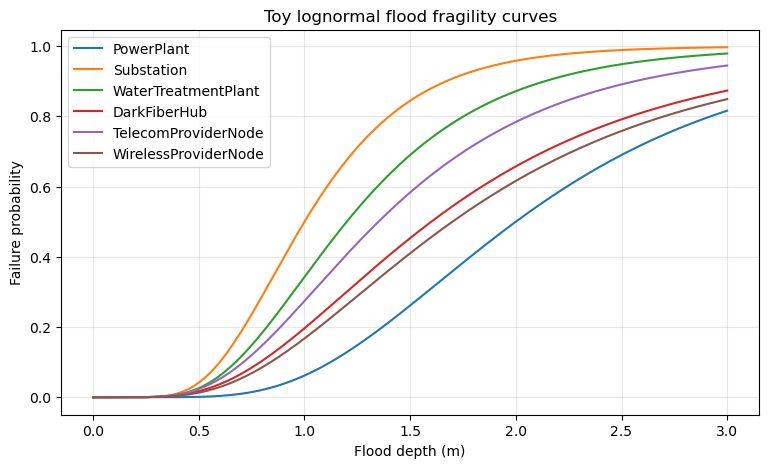

In [13]:
depth_grid = np.linspace(0, 3.0, 200)
plt.figure(figsize=(9, 5))
for _, row in fragility_parameters.iterrows():
    probs = [lognormal_fragility(d, row["median_depth_m"], row["beta"]) for d in depth_grid]
    plt.plot(depth_grid, probs, label=row["node_type"])

plt.xlabel("Flood depth (m)")
plt.ylabel("Failure probability")
plt.title("Toy lognormal flood fragility curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Bayesian Network parameters and exact inference

### How posterior probabilities are evaluated

The `evaluate_posteriors` function performs exact enumeration for this toy network:

1. Generate every possible assignment of the binary infrastructure variables.
2. Discard assignments that conflict with observed binary evidence, such as `SUB_1_failed = 1`.
3. Compute each remaining assignment's joint probability from root priors and conditional service models.
4. For `SUB_1_failed`, use the visible parent `PP_1_failed` plus the substation's own flood/routine failure probability inside the CPT.
5. For tier-functionality evidence, multiply the assignment weight by the likelihood of the observed tier state under that assignment.
6. Normalize all retained weights by the total evidence probability.
7. Sum normalized weights to obtain posterior probabilities for each binary variable and each tier-functionality state.

This is transparent and exact for the toy model. Larger networks would usually use a BN/DBN solver,
likelihood weighting, particle filtering, or another approximate inference method.

In [14]:
routine_probability_lookup = dict(zip(routine_failure_logs["variable"], routine_failure_logs["routine_p_failed"]))
tier_routine_lookup = dict(zip(
    zip(tier_routine_functionality_logs["tier_node"], tier_routine_functionality_logs["threshold"]),
    tier_routine_functionality_logs["routine_probability"],
))

substation_own_prior_t0 = float(
    node_fragility_input.loc[node_fragility_input["variable"] == "SUB_1_failed", "prior_p_failed"].iloc[0]
)
root_priors = {
    row["variable"]: float(row["prior_p_failed"])
    for row in node_fragility_input.to_dict("records")
    if row["variable"] != "SUB_1_failed"
}

def p_elicited(parameter_id):
    return float(elicited_probability_lookup[parameter_id])

def p_routine(variable):
    return float(routine_probability_lookup[variable])

def build_conditional_params(event_elapsed_hours=HURRICANE_EVENT_HOURS, substation_own_failure_probability=None):
    if substation_own_failure_probability is None:
        substation_own_failure_probability = substation_own_prior_t0

    return {
        "SUB_1_failed": {
            "type": "parent_or_prior",
            "parents": ["PP_1_failed"],
            "own_failure_probability": substation_own_failure_probability,
            "routine_failure_probability": 0.0,
            "interpretation": "Plant/transmission failure makes substation service unavailable; otherwise use substation own flood/routine risk.",
        },
        "WaterSupply_failed": {
            "type": "deterministic_or",
            "parents": ["WTP_1_failed"],
            "routine_failure_probability": p_routine("WaterSupply_failed"),
        },
        "Communication_Tier1_failed": {
            "type": "redundant_comm",
            "parents": ["LEE_DARK_FIBER_failed", "LUMEN_MPLS_failed", "COMCAST_ENS_failed"],
            "roles": [("primary", "LEE_DARK_FIBER_failed"), ("backup", "LUMEN_MPLS_failed"), ("backup", "COMCAST_ENS_failed")],
            "routine_failure_probability": p_routine("Communication_Tier1_failed"),
        },
        "Communication_Tier2_failed": {
            "type": "redundant_comm",
            "parents": ["LUMEN_MPLS_failed", "COMCAST_ENS_failed"],
            "roles": [("co_primary", "LUMEN_MPLS_failed"), ("co_primary", "COMCAST_ENS_failed")],
            "routine_failure_probability": p_routine("Communication_Tier2_failed"),
        },
        "Communication_Tier3_failed": {
            "type": "redundant_comm",
            "parents": ["LUMEN_MPLS_failed", "COMCAST_BUSINESS_failed", "TMOBILE_5G_failed"],
            "roles": [("primary", "LUMEN_MPLS_failed"), ("backup", "COMCAST_BUSINESS_failed"), ("backup", "TMOBILE_5G_failed")],
            "routine_failure_probability": p_routine("Communication_Tier3_failed"),
        },
        "Power_Tier1_failed": {
            "type": "generator_power",
            "parents": ["SUB_1_failed"],
            "event_elapsed_hours": event_elapsed_hours,
            "routine_failure_probability": p_routine("Power_Tier1_failed"),
        },
        "Power_Tier2_failed": {
            "type": "generator_power",
            "parents": ["SUB_1_failed"],
            "event_elapsed_hours": event_elapsed_hours,
            "routine_failure_probability": p_routine("Power_Tier2_failed"),
        },
        "Power_Tier3_failed": {
            "type": "generator_power",
            "parents": ["SUB_1_failed"],
            "event_elapsed_hours": event_elapsed_hours,
            "routine_failure_probability": p_routine("Power_Tier3_failed"),
        },
    }

conditional_params = build_conditional_params()
functionality_states = ["Normal", "Reduced", "Critical", "Failed"]
tier_variables = ["Tier1_Functionality", "Tier2_Functionality", "Tier3_Functionality"]

def tier_strengths(tier, threshold, parents):
    return [p_elicited(f"{tier}|{threshold}|{parent}") for parent in parents]

tier_parent_map = {
    "Tier1_Functionality": ["Power_Tier1_failed", "WaterSupply_failed", "Communication_Tier1_failed"],
    "Tier2_Functionality": ["Power_Tier2_failed", "WaterSupply_failed", "Communication_Tier2_failed"],
    "Tier3_Functionality": ["Power_Tier3_failed", "WaterSupply_failed", "Communication_Tier3_failed"],
}
tier_functionality_params = {}
for tier, parents in tier_parent_map.items():
    tier_functionality_params[tier] = {}
    for threshold in ["ge_reduced", "ge_critical", "ge_failed"]:
        tier_functionality_params[tier][threshold] = {
            "parents": parents,
            "strengths": tier_strengths(tier, threshold, parents),
            "routine_probability": tier_routine_lookup[(tier, threshold)],
        }

display(pd.DataFrame([{"variable": k, "prior_p_failed": v} for k, v in root_priors.items()]))
display(pd.DataFrame([{"component": "SUB_1_failed own CPT input", "prior_p_failed": substation_own_prior_t0}]))
display(pd.DataFrame([
    {"child": child, **spec}
    for child, spec in conditional_params.items()
]))

,variable,prior_p_failed
0,PP_1_failed,0.010730
1,WTP_1_failed,0.500571
2,LEE_DARK_FIBER_failed,0.037926
3,LUMEN_MPLS_failed,0.342408
4,COMCAST_ENS_failed,0.471126
5,COMCAST_BUSINESS_failed,0.718316
6,TMOBILE_5G_failed,0.086937


,component,prior_p_failed
0,SUB_1_failed own CPT input,0.844876


,child,type,parents,own_failure_probability,routine_failure_probability,interpretation,roles,event_elapsed_hours
0,SUB_1_failed,parent_or_prior,[PP_1_failed],0.844876,0.000000,Plant/transmission failure makes substation se...,NaN,NaN
1,WaterSupply_failed,deterministic_or,[WTP_1_failed],NaN,0.001142,NaN,NaN,NaN
2,Communication_Tier1_failed,redundant_comm,"[LEE_DARK_FIBER_failed, LUMEN_MPLS_failed, COM...",NaN,0.000571,NaN,"[(primary, LEE_DARK_FIBER_failed), (backup, LU...",NaN
3,Communication_Tier2_failed,redundant_comm,"[LUMEN_MPLS_failed, COMCAST_ENS_failed]",NaN,0.000913,NaN,"[(co_primary, LUMEN_MPLS_failed), (co_primary,...",NaN
4,Communication_Tier3_failed,redundant_comm,"[LUMEN_MPLS_failed, COMCAST_BUSINESS_failed, T...",NaN,0.001712,NaN,"[(primary, LUMEN_MPLS_failed), (backup, COMCAS...",NaN
5,Power_Tier1_failed,generator_power,[SUB_1_failed],NaN,0.000457,NaN,NaN,48.0
6,Power_Tier2_failed,generator_power,[SUB_1_failed],NaN,0.000571,NaN,NaN,48.0
7,Power_Tier3_failed,generator_power,[SUB_1_failed],NaN,0.000799,NaN,NaN,48.0


In [15]:
binary_variables = [
    "PP_1_failed",
    "SUB_1_failed",
    "WTP_1_failed",
    "LEE_DARK_FIBER_failed",
    "LUMEN_MPLS_failed",
    "COMCAST_ENS_failed",
    "COMCAST_BUSINESS_failed",
    "TMOBILE_5G_failed",
    "WaterSupply_failed",
    "Communication_Tier1_failed",
    "Communication_Tier2_failed",
    "Communication_Tier3_failed",
    "Power_Tier1_failed",
    "Power_Tier2_failed",
    "Power_Tier3_failed",
]

def conditional_binary_prob(var, value, assignment, priors, params):
    if var in priors:
        return bernoulli_prob(value, priors[var])

    spec = params[var]
    parent_values = [assignment[p] for p in spec["parents"]]
    routine_p = spec.get("routine_failure_probability", 0.0)

    if spec["type"] == "noisy_or":
        p_fail = noisy_or_failure(parent_values, spec["strengths"], routine_failure_probability=routine_p)
    elif spec["type"] == "deterministic_or":
        p_fail = 1.0 if any(parent_values) else routine_p
    elif spec["type"] == "parent_or_prior":
        p_fail = 1.0 if any(parent_values) else spec["own_failure_probability"]
    elif spec["type"] == "redundant_comm":
        p_fail = redundant_communication_failure(parent_values, spec["roles"], routine_p)
    elif spec["type"] == "generator_power":
        p_fail = generator_buffered_power_failure(parent_values[0], spec["event_elapsed_hours"], routine_p)
    else:
        raise ValueError(f"Unknown conditional type: {spec['type']}")
    return bernoulli_prob(value, p_fail)

def tier_distribution(tier_var, assignment):
    params = tier_functionality_params[tier_var]
    parent_values = [assignment[p] for p in params["ge_reduced"]["parents"]]
    return functionality_state_distribution(parent_values, params)

def iter_binary_assignments():
    for bits in itertools.product([0, 1], repeat=len(binary_variables)):
        yield dict(zip(binary_variables, bits))

def binary_assignment_probability(assignment, priors, params):
    p = 1.0
    for var in binary_variables:
        p *= conditional_binary_prob(var, assignment[var], assignment, priors, params)
    return p

def evaluate_posteriors(evidence=None, priors=None, params=None):
    if evidence is None:
        evidence = {}
    if priors is None:
        priors = root_priors
    if params is None:
        params = conditional_params

    binary_evidence = {k: v for k, v in evidence.items() if k in binary_variables}
    tier_evidence = {k: v for k, v in evidence.items() if k in tier_variables}
    denom = 0.0
    binary_numerators = {var: 0.0 for var in binary_variables}
    tier_numerators = {tier: {state: 0.0 for state in functionality_states} for tier in tier_variables}

    for assignment in iter_binary_assignments():
        if any(assignment[var] != observed for var, observed in binary_evidence.items()):
            continue
        binary_weight = binary_assignment_probability(assignment, priors, params)
        tier_likelihoods = {tier: tier_distribution(tier, assignment) for tier in tier_variables}

        evidence_likelihood = 1.0
        for tier, observed_state in tier_evidence.items():
            evidence_likelihood *= tier_likelihoods[tier][observed_state]
        weight = binary_weight * evidence_likelihood
        denom += weight

        for var in binary_variables:
            if assignment[var] == 1:
                binary_numerators[var] += weight
        for tier in tier_variables:
            if tier in tier_evidence:
                continue
            for state, p_state in tier_likelihoods[tier].items():
                tier_numerators[tier][state] += weight * p_state

    if denom == 0:
        raise ValueError("Evidence has zero probability under the current model.")

    binary_posteriors = {var: binary_numerators[var] / denom for var in binary_variables}
    tier_posteriors = {}
    for tier in tier_variables:
        if tier in tier_evidence:
            tier_posteriors[tier] = {state: float(state == tier_evidence[tier]) for state in functionality_states}
        else:
            tier_posteriors[tier] = {state: tier_numerators[tier][state] / denom for state in functionality_states}
    return binary_posteriors, tier_posteriors

def summarize_binary_posteriors(evidence=None, priors=None, params=None):
    binary_posteriors, _ = evaluate_posteriors(evidence, priors, params)
    return pd.DataFrame([{"variable": var, "p_failed_given_evidence": binary_posteriors[var]} for var in binary_variables])

def summarize_tier_functionality(evidence=None, priors=None, params=None):
    _, tier_posteriors = evaluate_posteriors(evidence, priors, params)
    return pd.DataFrame([
        {"tier_node": tier, "functionality_state": state, "probability": tier_posteriors[tier][state]}
        for tier in tier_variables
        for state in functionality_states
    ])

## 5. Prior inference and Monte Carlo simulation

This notebook uses two levels of prior inference.

First, the static BN prior uses the initial Hurricane Ian flood snapshot at `t_0`. This provides a
quick baseline for the network before observations arrive.

Second, the DBN section computes a time-series prior forecast over the full 48-hour event with no
observations. That time-series prior is the more appropriate baseline for posterior updating,
because the evidence arrives at specific hours and flood exposure changes over time.

Monte Carlo simulation answers the static prior question by random sampling instead of exact
enumeration. In this small toy network, exact inference is feasible and gives a deterministic
reference. Monte Carlo is included because larger HCI networks can have many more nodes and CPT
states, where sampling is often easier to scale and easier to explain as simulated hurricane
realizations.

Interpretation guide:

- Static prior inference gives a `t_0` baseline.
- Time-series prior inference gives the no-observation DBN forecast for each event hour.
- Posterior DBN inference updates that time-series prior when observations arrive.
- Monte Carlo estimates should be close to exact static prior inference; small differences are
  sampling noise.

In [16]:
prior_binary_summary = summarize_binary_posteriors()
prior_tier_summary = summarize_tier_functionality()
display(prior_binary_summary)
display(prior_tier_summary)

,variable,p_failed_given_evidence
0,PP_1_failed,0.010730
1,SUB_1_failed,0.846541
2,WTP_1_failed,0.500571
3,LEE_DARK_FIBER_failed,0.037926
4,LUMEN_MPLS_failed,0.342408
5,COMCAST_ENS_failed,0.471126
6,COMCAST_BUSINESS_failed,0.718316
7,TMOBILE_5G_failed,0.086937
8,WaterSupply_failed,0.501141
9,Communication_Tier1_failed,0.040970


,tier_node,functionality_state,probability
0,Tier1_Functionality,Normal,0.489463
1,Tier1_Functionality,Reduced,0.198173
2,Tier1_Functionality,Critical,0.219674
3,Tier1_Functionality,Failed,0.092690
4,Tier2_Functionality,Normal,0.437498
5,Tier2_Functionality,Reduced,0.269680
6,Tier2_Functionality,Critical,0.229209
7,Tier2_Functionality,Failed,0.063614
8,Tier3_Functionality,Normal,0.515217
9,Tier3_Functionality,Reduced,0.277540


**Interpretation of prior results**

The prior tables are the model's baseline forecast before using generator-start or boil-water
observations. The binary table highlights likely infrastructure/service failures. The tier table
shows how those service risks propagate to Normal, Reduced, Critical, and Failed functionality.
These values should be read as scenario-specific baseline probabilities, not as posterior claims
about what actually happened.

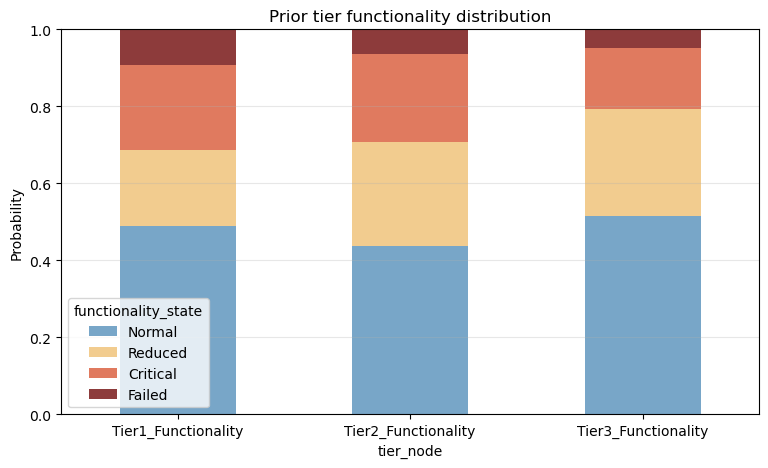

In [17]:
prior_tier_pivot = prior_tier_summary.pivot(index="tier_node", columns="functionality_state", values="probability")[functionality_states]
ax = prior_tier_pivot.plot(kind="bar", stacked=True, figsize=(9, 5), color=["#78a6c8", "#f2cc8f", "#e07a5f", "#8d3b3b"])
ax.set_ylabel("Probability")
ax.set_title("Prior tier functionality distribution")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.show()

In [18]:
def sample_categorical(prob_dict, rng):
    states = list(prob_dict.keys())
    probs = np.array([prob_dict[s] for s in states], dtype=float)
    probs = probs / probs.sum()
    return rng.choice(states, p=probs)

def sample_network_once(priors, params, rng):
    assignment = {}
    for var in binary_variables:
        p_fail = conditional_binary_prob(var, 1, assignment, priors, params)
        assignment[var] = int(rng.random() < p_fail)
    tier_states = {tier: sample_categorical(tier_distribution(tier, assignment), rng) for tier in tier_variables}
    return assignment, tier_states

def run_monte_carlo(n=30000, seed=20220928):
    rng = np.random.default_rng(seed)
    binary_counts = {var: 0 for var in binary_variables}
    tier_counts = {tier: {state: 0 for state in functionality_states} for tier in tier_variables}
    for _ in range(n):
        assignment, tier_states = sample_network_once(root_priors, conditional_params, rng)
        for var in binary_variables:
            binary_counts[var] += assignment[var]
        for tier, state in tier_states.items():
            tier_counts[tier][state] += 1
    binary_mc = pd.DataFrame([{"variable": var, "mc_p_failed": binary_counts[var] / n} for var in binary_variables])
    tier_mc = pd.DataFrame([
        {
            "tier_node": tier,
            "mc_p_normal": tier_counts[tier]["Normal"] / n,
            "mc_p_reduced": tier_counts[tier]["Reduced"] / n,
            "mc_p_critical": tier_counts[tier]["Critical"] / n,
            "mc_p_failed": tier_counts[tier]["Failed"] / n,
            "mc_p_critical_or_failed": (tier_counts[tier]["Critical"] + tier_counts[tier]["Failed"]) / n,
        }
        for tier in tier_variables
    ])
    return binary_mc, tier_mc

mc_binary_summary, mc_tier_summary = run_monte_carlo()
display(mc_binary_summary)
display(mc_tier_summary)

,variable,mc_p_failed
0,PP_1_failed,0.011000
1,SUB_1_failed,0.850400
2,WTP_1_failed,0.498067
3,LEE_DARK_FIBER_failed,0.035967
4,LUMEN_MPLS_failed,0.344333
5,COMCAST_ENS_failed,0.475700
6,COMCAST_BUSINESS_failed,0.718667
7,TMOBILE_5G_failed,0.086733
8,WaterSupply_failed,0.498633
9,Communication_Tier1_failed,0.041067


,tier_node,mc_p_normal,mc_p_reduced,mc_p_critical,mc_p_failed,mc_p_critical_or_failed
0,Tier1_Functionality,0.491133,0.1946,0.220100,0.094167,0.314267
1,Tier2_Functionality,0.435800,0.2735,0.226500,0.064200,0.290700
2,Tier3_Functionality,0.512167,0.2803,0.158067,0.049467,0.207533


**Interpretation of Monte Carlo results**

The Monte Carlo table estimates the same prior risk through repeated simulated network states.
`mc_p_critical_or_failed` is a compact summary of severe operational risk for each tier. If these
values diverge substantially from exact prior inference, increase the simulation size or inspect the
sampling logic.

## 6. Posterior updating with static observations

Posterior updating conditions the BN on observations. In the static example below, observing
`Tier1_Functionality = Critical` changes the probability of upstream causes. This is useful for
diagnostic inference: instead of only predicting hospital functionality from infrastructure, we can
ask which infrastructure failures become more plausible after a facility status report arrives.

In [19]:
evidence_tier1_critical = {"Tier1_Functionality": "Critical"}
posterior_failures_given_tier1_critical = summarize_binary_posteriors(evidence=evidence_tier1_critical)
display(posterior_failures_given_tier1_critical.sort_values("p_failed_given_evidence", ascending=False))

,variable,p_failed_given_evidence
8,WaterSupply_failed,0.958241
2,WTP_1_failed,0.957150
1,SUB_1_failed,0.848681
6,COMCAST_BUSINESS_failed,0.718316
5,COMCAST_ENS_failed,0.477811
4,LUMEN_MPLS_failed,0.348852
10,Communication_Tier2_failed,0.203971
11,Communication_Tier3_failed,0.118022
7,TMOBILE_5G_failed,0.086937
12,Power_Tier1_failed,0.081261


**Interpretation of static posterior results**

Variables with larger posterior probabilities after observing Tier 1 critical functionality are
more consistent with that observation. This does not prove causation; it ranks which modeled causes
the BN finds most plausible given the evidence and prior assumptions.

## 7. Dynamic Bayesian Network inputs for 48 hours of Hurricane Ian

In [20]:
time_points = [
    (0, "2022-09-28 00:00"),
    (6, "2022-09-28 06:00"),
    (12, "2022-09-28 12:00"),
    (18, "2022-09-28 18:00"),
    (24, "2022-09-29 00:00"),
    (30, "2022-09-29 06:00"),
    (36, "2022-09-29 12:00"),
    (42, "2022-09-29 18:00"),
    (48, "2022-09-30 00:00"),
]

depth_profiles = {
    "PP_1": [0.40, 0.70, 1.10, 1.30, 1.10, 0.90, 0.60, 0.35, 0.20],
    "SUB_1": [0.80, 1.20, 1.80, 2.10, 1.90, 1.50, 1.00, 0.65, 0.35],
    "WTP_1": [0.60, 1.00, 1.50, 1.80, 1.60, 1.20, 0.80, 0.45, 0.25],
    "LEE_DARK_FIBER": [0.20, 0.40, 0.70, 0.90, 0.75, 0.55, 0.35, 0.20, 0.10],
    "LUMEN_MPLS": [0.50, 0.90, 1.30, 1.70, 1.50, 1.10, 0.70, 0.40, 0.20],
    "COMCAST_ENS": [0.60, 1.00, 1.50, 1.90, 1.70, 1.20, 0.75, 0.45, 0.25],
    "COMCAST_BUSINESS": [0.70, 1.20, 1.80, 2.30, 2.00, 1.50, 0.95, 0.55, 0.30],
    "TMOBILE_5G": [0.30, 0.60, 0.90, 1.20, 1.00, 0.75, 0.45, 0.25, 0.10],
}

dbn_flood_depth = pd.DataFrame([
    {"time_step": i, "event_hour": hour, "timestamp": timestamp, "node_id": node_id, "flood_depth_m": depths[i], "source": "hydrodynamic_model"}
    for i, (hour, timestamp) in enumerate(time_points)
    for node_id, depths in depth_profiles.items()
])

dbn_observations = pd.DataFrame([
    {"time_step": 1, "event_hour": 6, "timestamp": "2022-09-28 06:30", "variable": "SUB_1_failed", "observed_value": 1, "source": "facility generator log", "confidence": 0.95, "notes": "Generators started; interpreted as evidence that substation service to the hospital system is unavailable."},
    {"time_step": 3, "event_hour": 18, "timestamp": "2022-09-28 18:30", "variable": "WaterSupply_failed", "observed_value": 1, "source": "public boil-water notice", "confidence": 0.90, "notes": "Boil-water notice treated as evidence of potable water-service failure or severe degradation."},
])

display(dbn_flood_depth.head(16))
display(dbn_observations)

,time_step,event_hour,timestamp,node_id,flood_depth_m,source
0,0,0,2022-09-28 00:00,PP_1,0.4,hydrodynamic_model
1,0,0,2022-09-28 00:00,SUB_1,0.8,hydrodynamic_model
2,0,0,2022-09-28 00:00,WTP_1,0.6,hydrodynamic_model
3,0,0,2022-09-28 00:00,LEE_DARK_FIBER,0.2,hydrodynamic_model
4,0,0,2022-09-28 00:00,LUMEN_MPLS,0.5,hydrodynamic_model
5,0,0,2022-09-28 00:00,COMCAST_ENS,0.6,hydrodynamic_model
6,0,0,2022-09-28 00:00,COMCAST_BUSINESS,0.7,hydrodynamic_model
7,0,0,2022-09-28 00:00,TMOBILE_5G,0.3,hydrodynamic_model
8,1,6,2022-09-28 06:00,PP_1,0.7,hydrodynamic_model
9,1,6,2022-09-28 06:00,SUB_1,1.2,hydrodynamic_model


,time_step,event_hour,timestamp,variable,observed_value,source,confidence,notes
0,1,6,2022-09-28 06:30,SUB_1_failed,1,facility generator log,0.95,Generators started; interpreted as evidence th...
1,3,18,2022-09-28 18:30,WaterSupply_failed,1,public boil-water notice,0.90,Boil-water notice treated as evidence of potab...


In [21]:
transition_parameters = pd.DataFrame([
    {"node_type": "PowerPlant", "p_recover_per_step": 0.08, "source": "expert_elicitation", "rationale": "Power plant recovery may be slow after flood damage"},
    {"node_type": "Substation", "p_recover_per_step": 0.12, "source": "expert_elicitation", "rationale": "Substation inspection and repair may take time"},
    {"node_type": "WaterTreatmentPlant", "p_recover_per_step": 0.10, "source": "expert_elicitation", "rationale": "Water treatment recovery depends on equipment and water quality"},
    {"node_type": "DarkFiberHub", "p_recover_per_step": 0.18, "source": "expert_elicitation", "rationale": "Fiber recovery may require field access and splicing"},
    {"node_type": "TelecomProviderNode", "p_recover_per_step": 0.20, "source": "expert_elicitation", "rationale": "Telecom provider recovery may use portable power and rerouting"},
    {"node_type": "WirelessProviderNode", "p_recover_per_step": 0.24, "source": "expert_elicitation", "rationale": "Wireless sites may recover faster through portable generators or mobile assets"},
])

root_variable_metadata = pd.DataFrame([
    {"root_variable": "PP_1_failed", "node_id": "PP_1", "node_type": "PowerPlant"},
    {"root_variable": "WTP_1_failed", "node_id": "WTP_1", "node_type": "WaterTreatmentPlant"},
    {"root_variable": "LEE_DARK_FIBER_failed", "node_id": "LEE_DARK_FIBER", "node_type": "DarkFiberHub"},
    {"root_variable": "LUMEN_MPLS_failed", "node_id": "LUMEN_MPLS", "node_type": "TelecomProviderNode"},
    {"root_variable": "COMCAST_ENS_failed", "node_id": "COMCAST_ENS", "node_type": "TelecomProviderNode"},
    {"root_variable": "COMCAST_BUSINESS_failed", "node_id": "COMCAST_BUSINESS", "node_type": "TelecomProviderNode"},
    {"root_variable": "TMOBILE_5G_failed", "node_id": "TMOBILE_5G", "node_type": "WirelessProviderNode"},
])

substation_own_metadata = {"root_variable": "SUB_1_failed", "node_id": "SUB_1", "node_type": "Substation"}

display(transition_parameters)
display(root_variable_metadata)
display(pd.DataFrame([substation_own_metadata]).rename(columns={"root_variable": "conditional_node"}))

,node_type,p_recover_per_step,source,rationale
0,PowerPlant,0.08,expert_elicitation,Power plant recovery may be slow after flood d...
1,Substation,0.12,expert_elicitation,Substation inspection and repair may take time
2,WaterTreatmentPlant,0.10,expert_elicitation,Water treatment recovery depends on equipment ...
3,DarkFiberHub,0.18,expert_elicitation,Fiber recovery may require field access and sp...
4,TelecomProviderNode,0.20,expert_elicitation,Telecom provider recovery may use portable pow...
5,WirelessProviderNode,0.24,expert_elicitation,Wireless sites may recover faster through port...


,root_variable,node_id,node_type
0,PP_1_failed,PP_1,PowerPlant
1,WTP_1_failed,WTP_1,WaterTreatmentPlant
2,LEE_DARK_FIBER_failed,LEE_DARK_FIBER,DarkFiberHub
3,LUMEN_MPLS_failed,LUMEN_MPLS,TelecomProviderNode
4,COMCAST_ENS_failed,COMCAST_ENS,TelecomProviderNode
5,COMCAST_BUSINESS_failed,COMCAST_BUSINESS,TelecomProviderNode
6,TMOBILE_5G_failed,TMOBILE_5G,WirelessProviderNode


,conditional_node,node_id,node_type
0,SUB_1_failed,SUB_1,Substation


## 8. DBN-style filtering, time-series prior, and evidence update

The DBN filter updates probabilities over time. At each 6-hour slice, it:

1. recomputes flood-driven root priors from the current flood depth;
2. carries forward previous root posterior probabilities with recovery assumptions;
3. recomputes the substation's own flood/routine failure probability as the internal CPT input for `SUB_1_failed`;
4. applies any observations at that time step as hard evidence;
5. propagates updated service probabilities into tier functionality probabilities.

The notebook runs the filter twice:

- `dbn_prior_results`: no observations, representing the time-series prior forecast;
- `dbn_results`: with observations, representing the posterior update.

Observation comments:

- Hour 6 generator start is represented as `SUB_1_failed = 1`. This follows the revised structure:
  substation service loss activates tier generators, and generators buffer tier power failures for
  the five-day runtime window.
- Hour 18 boil-water notice is represented as `WaterSupply_failed = 1`. This directly increases
  the probability of reduced, critical, or failed functionality across all tiers because water has
  no modeled backup.

In [22]:
def variable_prior_from_flood_and_routine(t, variable, node_id, node_type):
    df = (
        dbn_flood_depth[dbn_flood_depth["time_step"] == t]
        .merge(asset_inventory[["node_id", "node_type"]], on="node_id", how="left")
        .merge(fragility_parameters, on="node_type", how="left")
    )
    row = df[df["node_id"] == node_id].iloc[0]
    p_fragility = lognormal_fragility(row["flood_depth_m"], row["median_depth_m"], row["beta"])
    return combine_independent_probabilities(p_fragility, p_routine(variable))

def compute_fragility_priors_for_time(t):
    priors = {}
    for _, meta in root_variable_metadata.iterrows():
        priors[meta["root_variable"]] = variable_prior_from_flood_and_routine(
            t,
            meta["root_variable"],
            meta["node_id"],
            meta["node_type"],
        )
    return priors

def compute_substation_own_failure_probability_for_time(t):
    return variable_prior_from_flood_and_routine(
        t,
        substation_own_metadata["root_variable"],
        substation_own_metadata["node_id"],
        substation_own_metadata["node_type"],
    )

def recovery_access_factor(event_hour):
    if event_hour <= 24:
        return 0.20
    if event_hour <= 36:
        return 0.50
    return 1.00

def temporal_update_root_prior(previous_p_failed, event_prior_p_failed, p_recover, event_hour):
    effective_recovery = p_recover * recovery_access_factor(event_hour)
    p_fail_if_prev_ok = event_prior_p_failed
    p_fail_if_prev_failed = 1.0 - effective_recovery * (1.0 - event_prior_p_failed)
    return previous_p_failed * p_fail_if_prev_failed + (1.0 - previous_p_failed) * p_fail_if_prev_ok

def get_time_step_evidence(t):
    evidence = {}
    for _, row in dbn_observations[dbn_observations["time_step"] == t].iterrows():
        evidence[row["variable"]] = row["observed_value"]
    return evidence

def dbn_filter():
    time_steps = sorted(dbn_flood_depth["time_step"].unique())
    previous_root_posterior = None
    previous_substation_own_prior = None
    results = []
    root_prior_records = []

    for t in time_steps:
        event_hour = int(dbn_flood_depth.loc[dbn_flood_depth["time_step"] == t, "event_hour"].iloc[0])
        event_root_priors = compute_fragility_priors_for_time(t)
        event_substation_own_prior = compute_substation_own_failure_probability_for_time(t)

        if previous_root_posterior is None:
            dynamic_root_priors = event_root_priors.copy()
            dynamic_substation_own_prior = event_substation_own_prior
        else:
            dynamic_root_priors = {}
            for _, meta in root_variable_metadata.iterrows():
                var = meta["root_variable"]
                p_recover = transition_parameters.loc[transition_parameters["node_type"] == meta["node_type"], "p_recover_per_step"].iloc[0]
                dynamic_root_priors[var] = temporal_update_root_prior(previous_root_posterior[var], event_root_priors[var], p_recover, event_hour)

            substation_recover = transition_parameters.loc[
                transition_parameters["node_type"] == substation_own_metadata["node_type"],
                "p_recover_per_step",
            ].iloc[0]
            dynamic_substation_own_prior = temporal_update_root_prior(
                previous_substation_own_prior,
                event_substation_own_prior,
                substation_recover,
                event_hour,
            )

        for var, p in dynamic_root_priors.items():
            root_prior_records.append({"time_step": t, "event_hour": event_hour, "variable": var, "dynamic_prior_p_failed": p, "event_prior_p_failed": event_root_priors[var], "role": "root prior"})
        root_prior_records.append({
            "time_step": t,
            "event_hour": event_hour,
            "variable": "SUB_1_failed",
            "dynamic_prior_p_failed": dynamic_substation_own_prior,
            "event_prior_p_failed": event_substation_own_prior,
            "role": "own-failure CPT input",
        })

        evidence = get_time_step_evidence(t)
        params_t = build_conditional_params(
            event_elapsed_hours=event_hour,
            substation_own_failure_probability=dynamic_substation_own_prior,
        )
        binary_posteriors, tier_posteriors = evaluate_posteriors(evidence=evidence, priors=dynamic_root_priors, params=params_t)

        record = {"time_step": t, "event_hour": event_hour, "evidence": evidence}
        for tier in tier_variables:
            for state in functionality_states:
                record[f"P_{tier}_{state}"] = tier_posteriors[tier][state]
        for var in ["SUB_1_failed", "WaterSupply_failed", "Communication_Tier1_failed", "Communication_Tier2_failed", "Communication_Tier3_failed", "Power_Tier1_failed", "Power_Tier2_failed", "Power_Tier3_failed"]:
            record[f"P_{var}"] = binary_posteriors[var]
        results.append(record)

        previous_root_posterior = {var: binary_posteriors[var] for var in root_priors}
        previous_substation_own_prior = dynamic_substation_own_prior

    return pd.DataFrame(results), pd.DataFrame(root_prior_records)

# Time-series prior forecast: run the DBN with no observations.
dbn_observations_with_evidence = dbn_observations.copy()
dbn_observations = dbn_observations.iloc[0:0].copy()
dbn_prior_results, dbn_prior_root_priors = dbn_filter()

# Posterior forecast: restore event observations and run the DBN again.
dbn_observations = dbn_observations_with_evidence
dbn_results, dbn_root_priors = dbn_filter()

display(dbn_prior_results)
display(dbn_results)
display(dbn_root_priors.head(18))

,time_step,event_hour,evidence,P_Tier1_Functionality_Normal,P_Tier1_Functionality_Reduced,P_Tier1_Functionality_Critical,P_Tier1_Functionality_Failed,P_Tier2_Functionality_Normal,P_Tier2_Functionality_Reduced,P_Tier2_Functionality_Critical,P_Tier2_Functionality_Failed,P_Tier3_Functionality_Normal,P_Tier3_Functionality_Reduced,P_Tier3_Functionality_Critical,P_Tier3_Functionality_Failed,P_SUB_1_failed,P_WaterSupply_failed,P_Communication_Tier1_failed,P_Communication_Tier2_failed,P_Communication_Tier3_failed,P_Power_Tier1_failed,P_Power_Tier2_failed,P_Power_Tier3_failed
0,0,0,{},0.910768,0.042765,0.033581,0.012886,0.903551,0.054706,0.033008,0.008736,0.904538,0.060726,0.026916,0.007820,0.290380,0.063881,0.003514,0.009921,0.009870,0.023687,0.023801,0.024029
1,1,6,{},0.601561,0.157929,0.169596,0.070914,0.568402,0.213634,0.171466,0.046498,0.621077,0.221163,0.121721,0.036039,0.770500,0.384549,0.021393,0.107077,0.067362,0.062097,0.062211,0.062439
2,2,12,{},0.215202,0.289605,0.346381,0.148812,0.167749,0.360365,0.364574,0.107311,0.278745,0.396650,0.245795,0.078810,0.984101,0.807059,0.082192,0.430480,0.214046,0.079185,0.079299,0.079527
3,3,18,{},0.076047,0.324272,0.415738,0.183943,0.049495,0.360569,0.448500,0.141436,0.144076,0.439326,0.306135,0.110463,0.999022,0.961622,0.217978,0.748680,0.443802,0.080378,0.080493,0.080721
4,4,24,{},0.055048,0.324688,0.428293,0.191971,0.034574,0.352744,0.463962,0.148720,0.118639,0.440245,0.320557,0.120559,0.999068,0.984969,0.284379,0.832062,0.536469,0.080382,0.080496,0.080725
5,5,30,{},0.068141,0.322968,0.420969,0.187922,0.045092,0.358564,0.452868,0.143476,0.132295,0.438661,0.313100,0.115944,0.993669,0.967925,0.265842,0.772450,0.498621,0.079950,0.080064,0.080293
6,6,36,{},0.095604,0.318746,0.405989,0.179661,0.068129,0.365880,0.431961,0.134030,0.161959,0.433873,0.297682,0.106487,0.976731,0.934440,0.224928,0.669837,0.420451,0.078595,0.078709,0.078938
7,7,42,{},0.174291,0.300232,0.366118,0.159359,0.142119,0.365913,0.379467,0.112502,0.242286,0.409790,0.261023,0.086901,0.909573,0.843615,0.151106,0.460677,0.275582,0.073222,0.073337,0.073565
8,8,48,{},0.251015,0.277731,0.329419,0.141836,0.222092,0.348989,0.333360,0.095558,0.317417,0.379059,0.230551,0.072973,0.831838,0.759702,0.105188,0.317758,0.188028,0.067004,0.067118,0.067346


,time_step,event_hour,evidence,P_Tier1_Functionality_Normal,P_Tier1_Functionality_Reduced,P_Tier1_Functionality_Critical,P_Tier1_Functionality_Failed,P_Tier2_Functionality_Normal,P_Tier2_Functionality_Reduced,P_Tier2_Functionality_Critical,P_Tier2_Functionality_Failed,P_Tier3_Functionality_Normal,P_Tier3_Functionality_Reduced,P_Tier3_Functionality_Critical,P_Tier3_Functionality_Failed,P_SUB_1_failed,P_WaterSupply_failed,P_Communication_Tier1_failed,P_Communication_Tier2_failed,P_Communication_Tier3_failed,P_Power_Tier1_failed,P_Power_Tier2_failed,P_Power_Tier3_failed
0,0,0,{},0.910768,0.042765,0.033581,0.012886,0.903551,0.054706,0.033008,0.008736,0.904538,0.060726,0.026916,0.007820,0.290380,0.063881,0.003514,0.009921,0.009870,0.023687,0.023801,0.024029
1,1,6,{'SUB_1_failed': 1},0.597480,0.160746,0.170538,0.071236,0.564545,0.216189,0.172437,0.046829,0.616253,0.223950,0.123410,0.036386,1.000000,0.384549,0.021393,0.107077,0.067362,0.080457,0.080571,0.080799
2,2,12,{},0.215201,0.289605,0.346381,0.148812,0.167749,0.360365,0.364574,0.107312,0.278744,0.396651,0.245795,0.078810,0.984156,0.807059,0.082192,0.430480,0.214046,0.079189,0.079303,0.079532
3,3,18,{'WaterSupply_failed': 1},0.047626,0.331737,0.430087,0.190549,0.036341,0.360458,0.458286,0.144915,0.124818,0.447773,0.314438,0.112972,0.999025,1.000000,0.217978,0.748680,0.443802,0.080379,0.080493,0.080721
4,4,24,{},0.048245,0.326245,0.431859,0.193651,0.031774,0.352280,0.466343,0.149603,0.114228,0.441979,0.322598,0.121194,0.999071,0.994774,0.284379,0.832062,0.536469,0.080382,0.080496,0.080725
5,5,30,{},0.064852,0.323754,0.422674,0.188720,0.043573,0.358492,0.454038,0.143897,0.130103,0.439567,0.314084,0.116246,0.993689,0.972578,0.265842,0.772450,0.498621,0.079952,0.080066,0.080294
6,6,36,{},0.092951,0.319434,0.407333,0.180281,0.066698,0.366022,0.432922,0.134359,0.160102,0.434706,0.298469,0.106723,0.976800,0.938043,0.224928,0.669837,0.420451,0.078601,0.078715,0.078943
7,7,42,{},0.171770,0.300974,0.367345,0.159912,0.140389,0.366398,0.380415,0.112797,0.240375,0.410748,0.261763,0.087114,0.909812,0.846807,0.151106,0.460677,0.275582,0.073242,0.073356,0.073584
8,8,48,{},0.248648,0.278474,0.330544,0.142334,0.220250,0.349649,0.334273,0.095827,0.315551,0.380044,0.231240,0.073166,0.832233,0.762570,0.105188,0.317758,0.188028,0.067035,0.067149,0.067378


,time_step,event_hour,variable,dynamic_prior_p_failed,event_prior_p_failed,role
0,0,0,PP_1_failed,0.001087,0.001087,root prior
1,0,0,WTP_1_failed,0.062811,0.062811,root prior
2,0,0,LEE_DARK_FIBER_failed,0.000763,0.000763,root prior
3,0,0,LUMEN_MPLS_failed,0.025495,0.025495,root prior
4,0,0,COMCAST_ENS_failed,0.054580,0.054580,root prior
5,0,0,COMCAST_BUSINESS_failed,0.097185,0.097185,root prior
6,0,0,TMOBILE_5G_failed,0.002631,0.002631,root prior
7,0,0,SUB_1_failed,0.289608,0.289608,own-failure CPT input
8,1,6,PP_1_failed,0.011788,0.010730,root prior
9,1,6,WTP_1_failed,0.383846,0.343431,root prior


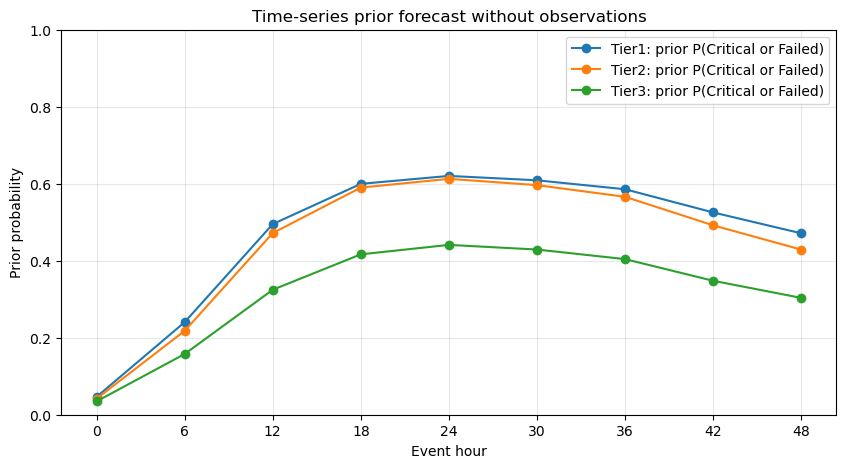

In [23]:
# Plot the time-series prior forecast before observations are applied.
plt.figure(figsize=(10, 5))
for tier in ["Tier1", "Tier2", "Tier3"]:
    plt.plot(
        dbn_prior_results["event_hour"],
        dbn_prior_results[f"P_{tier}_Functionality_Critical"] + dbn_prior_results[f"P_{tier}_Functionality_Failed"],
        marker="o",
        label=f"{tier}: prior P(Critical or Failed)",
    )

plt.xlabel("Event hour")
plt.ylabel("Prior probability")
plt.title("Time-series prior forecast without observations")
plt.xticks(dbn_prior_results["event_hour"])
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Interpretation of time-series prior results**

This plot is the DBN prior forecast across the 48-hour event. It uses changing flood depth,
routine failure probabilities, and recovery assumptions, but it does not use generator-start or
boil-water evidence. This is the baseline that the posterior update should be compared against.

**Interpretation of DBN posterior results**

Rows with non-empty `evidence` show time steps where observations override or sharpen the model's
forecast. At hour 6, observed generator activation is treated as evidence that `SUB_1_failed = 1`
for that time slice, which raises the probability of substation service loss while tier generators
buffer the direct tier power failure probability. At hour 18, `WaterSupply_failed = 1` makes the
shared water chain unavailable and pushes all three tier functionality distributions toward more
severe states. Later rows show how those observations, flood trajectory, persistence, and recovery
shape the sequential filter.

In [24]:
posterior_evidence_summary = dbn_results[[
    "time_step", "event_hour", "evidence", "P_SUB_1_failed", "P_WaterSupply_failed",
    "P_Power_Tier1_failed", "P_Power_Tier2_failed", "P_Power_Tier3_failed",
    "P_Tier1_Functionality_Normal", "P_Tier1_Functionality_Reduced", "P_Tier1_Functionality_Critical", "P_Tier1_Functionality_Failed",
    "P_Tier2_Functionality_Normal", "P_Tier2_Functionality_Reduced", "P_Tier2_Functionality_Critical", "P_Tier2_Functionality_Failed",
    "P_Tier3_Functionality_Normal", "P_Tier3_Functionality_Reduced", "P_Tier3_Functionality_Critical", "P_Tier3_Functionality_Failed",
]].copy()

for tier in ["Tier1", "Tier2", "Tier3"]:
    posterior_evidence_summary[f"P_{tier}_Critical_or_Failed"] = (
        posterior_evidence_summary[f"P_{tier}_Functionality_Critical"] +
        posterior_evidence_summary[f"P_{tier}_Functionality_Failed"]
    )

display(posterior_evidence_summary)

,time_step,event_hour,evidence,P_SUB_1_failed,P_WaterSupply_failed,P_Power_Tier1_failed,P_Power_Tier2_failed,P_Power_Tier3_failed,P_Tier1_Functionality_Normal,P_Tier1_Functionality_Reduced,P_Tier1_Functionality_Critical,P_Tier1_Functionality_Failed,P_Tier2_Functionality_Normal,P_Tier2_Functionality_Reduced,P_Tier2_Functionality_Critical,P_Tier2_Functionality_Failed,P_Tier3_Functionality_Normal,P_Tier3_Functionality_Reduced,P_Tier3_Functionality_Critical,P_Tier3_Functionality_Failed,P_Tier1_Critical_or_Failed,P_Tier2_Critical_or_Failed,P_Tier3_Critical_or_Failed
0,0,0,{},0.290380,0.063881,0.023687,0.023801,0.024029,0.910768,0.042765,0.033581,0.012886,0.903551,0.054706,0.033008,0.008736,0.904538,0.060726,0.026916,0.007820,0.046467,0.041743,0.034735
1,1,6,{'SUB_1_failed': 1},1.000000,0.384549,0.080457,0.080571,0.080799,0.597480,0.160746,0.170538,0.071236,0.564545,0.216189,0.172437,0.046829,0.616253,0.223950,0.123410,0.036386,0.241774,0.219266,0.159796
2,2,12,{},0.984156,0.807059,0.079189,0.079303,0.079532,0.215201,0.289605,0.346381,0.148812,0.167749,0.360365,0.364574,0.107312,0.278744,0.396651,0.245795,0.078810,0.495193,0.471885,0.324605
3,3,18,{'WaterSupply_failed': 1},0.999025,1.000000,0.080379,0.080493,0.080721,0.047626,0.331737,0.430087,0.190549,0.036341,0.360458,0.458286,0.144915,0.124818,0.447773,0.314438,0.112972,0.620636,0.603201,0.427409
4,4,24,{},0.999071,0.994774,0.080382,0.080496,0.080725,0.048245,0.326245,0.431859,0.193651,0.031774,0.352280,0.466343,0.149603,0.114228,0.441979,0.322598,0.121194,0.625510,0.615947,0.443793
5,5,30,{},0.993689,0.972578,0.079952,0.080066,0.080294,0.064852,0.323754,0.422674,0.188720,0.043573,0.358492,0.454038,0.143897,0.130103,0.439567,0.314084,0.116246,0.611394,0.597935,0.430330
6,6,36,{},0.976800,0.938043,0.078601,0.078715,0.078943,0.092951,0.319434,0.407333,0.180281,0.066698,0.366022,0.432922,0.134359,0.160102,0.434706,0.298469,0.106723,0.587614,0.567280,0.405192
7,7,42,{},0.909812,0.846807,0.073242,0.073356,0.073584,0.171770,0.300974,0.367345,0.159912,0.140389,0.366398,0.380415,0.112797,0.240375,0.410748,0.261763,0.087114,0.527257,0.493213,0.348877
8,8,48,{},0.832233,0.762570,0.067035,0.067149,0.067378,0.248648,0.278474,0.330544,0.142334,0.220250,0.349649,0.334273,0.095827,0.315551,0.380044,0.231240,0.073166,0.472878,0.430100,0.304405


In [25]:
# Compare the DBN time-series prior forecast against the posterior DBN with observations.
# This isolates how the generator-start and boil-water observations update the dynamic probabilities.
dbn_results_with_observations = dbn_results.copy()
dbn_results_without_observations = dbn_prior_results.copy()

comparison_records = []
for tier in ["Tier1", "Tier2", "Tier3"]:
    prior_col = f"{tier}_prior_no_observation"
    posterior_col = f"{tier}_posterior_with_observation"
    delta_col = f"{tier}_posterior_minus_prior"
    tmp = pd.DataFrame({
        "event_hour": dbn_results_with_observations["event_hour"],
        "tier": tier,
        "evidence": dbn_results_with_observations["evidence"],
        prior_col: (
            dbn_results_without_observations[f"P_{tier}_Functionality_Critical"] +
            dbn_results_without_observations[f"P_{tier}_Functionality_Failed"]
        ),
        posterior_col: (
            dbn_results_with_observations[f"P_{tier}_Functionality_Critical"] +
            dbn_results_with_observations[f"P_{tier}_Functionality_Failed"]
        ),
    })
    tmp[delta_col] = tmp[posterior_col] - tmp[prior_col]
    tmp = tmp.rename(columns={
        prior_col: "P_Critical_or_Failed_time_series_prior",
        posterior_col: "P_Critical_or_Failed_posterior",
        delta_col: "posterior_minus_time_series_prior",
    })
    comparison_records.append(tmp)

prior_posterior_comparison = pd.concat(comparison_records, ignore_index=True)
display(prior_posterior_comparison)

,event_hour,tier,evidence,P_Critical_or_Failed_time_series_prior,P_Critical_or_Failed_posterior,posterior_minus_time_series_prior
0,0,Tier1,{},0.046467,0.046467,0.000000e+00
1,6,Tier1,{'SUB_1_failed': 1},0.240510,0.241774,1.264105e-03
2,12,Tier1,{},0.495193,0.495193,2.037872e-07
3,18,Tier1,{'WaterSupply_failed': 1},0.599681,0.620636,2.095528e-02
4,24,Tier1,{},0.620264,0.625510,5.245711e-03
5,30,Tier1,{},0.608891,0.611394,2.503355e-03
6,36,Tier1,{},0.585650,0.587614,1.963809e-03
7,42,Tier1,{},0.525477,0.527257,1.780240e-03
8,48,Tier1,{},0.471254,0.472878,1.623595e-03
9,0,Tier2,{},0.041743,0.041743,0.000000e+00


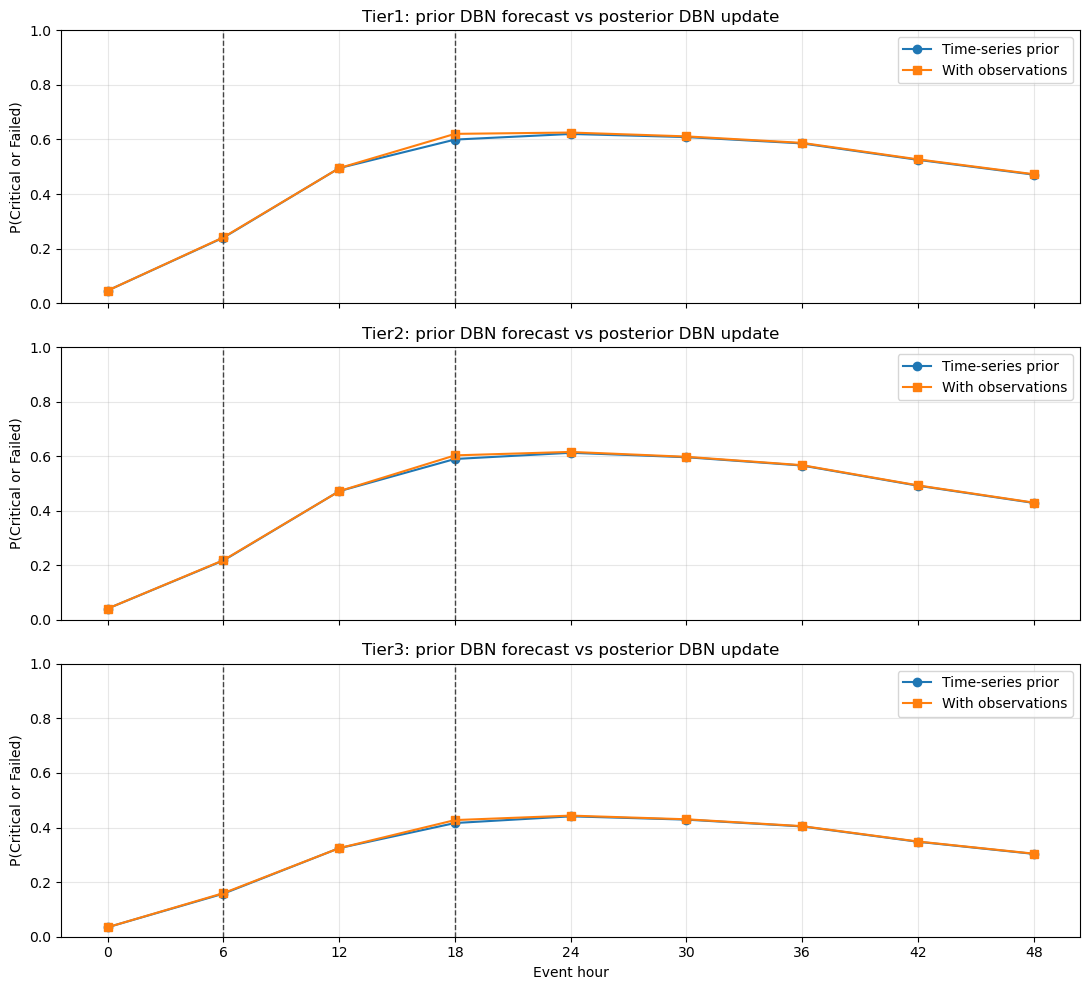

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
for ax, tier in zip(axes, ["Tier1", "Tier2", "Tier3"]):
    tmp = prior_posterior_comparison[prior_posterior_comparison["tier"] == tier]
    ax.plot(
        tmp["event_hour"],
        tmp["P_Critical_or_Failed_time_series_prior"],
        marker="o",
        label="Time-series prior",
    )
    ax.plot(
        tmp["event_hour"],
        tmp["P_Critical_or_Failed_posterior"],
        marker="s",
        label="With observations",
    )
    ax.axvline(6, color="#444444", linestyle="--", linewidth=1)
    ax.axvline(18, color="#444444", linestyle="--", linewidth=1)
    ax.set_title(f"{tier}: prior DBN forecast vs posterior DBN update")
    ax.set_ylabel("P(Critical or Failed)")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Event hour")
plt.xticks(dbn_results_with_observations["event_hour"])
plt.tight_layout()
plt.show()

**Interpretation of prior-vs-posterior comparison**

The no-observation line is the DBN forecast using only flood trajectory, routine failure rates, and
recovery assumptions. The posterior line adds the hour-6 generator-start evidence and hour-18
boil-water evidence. The difference column quantifies how much the observations move the estimated
probability of each tier being Critical or Failed.

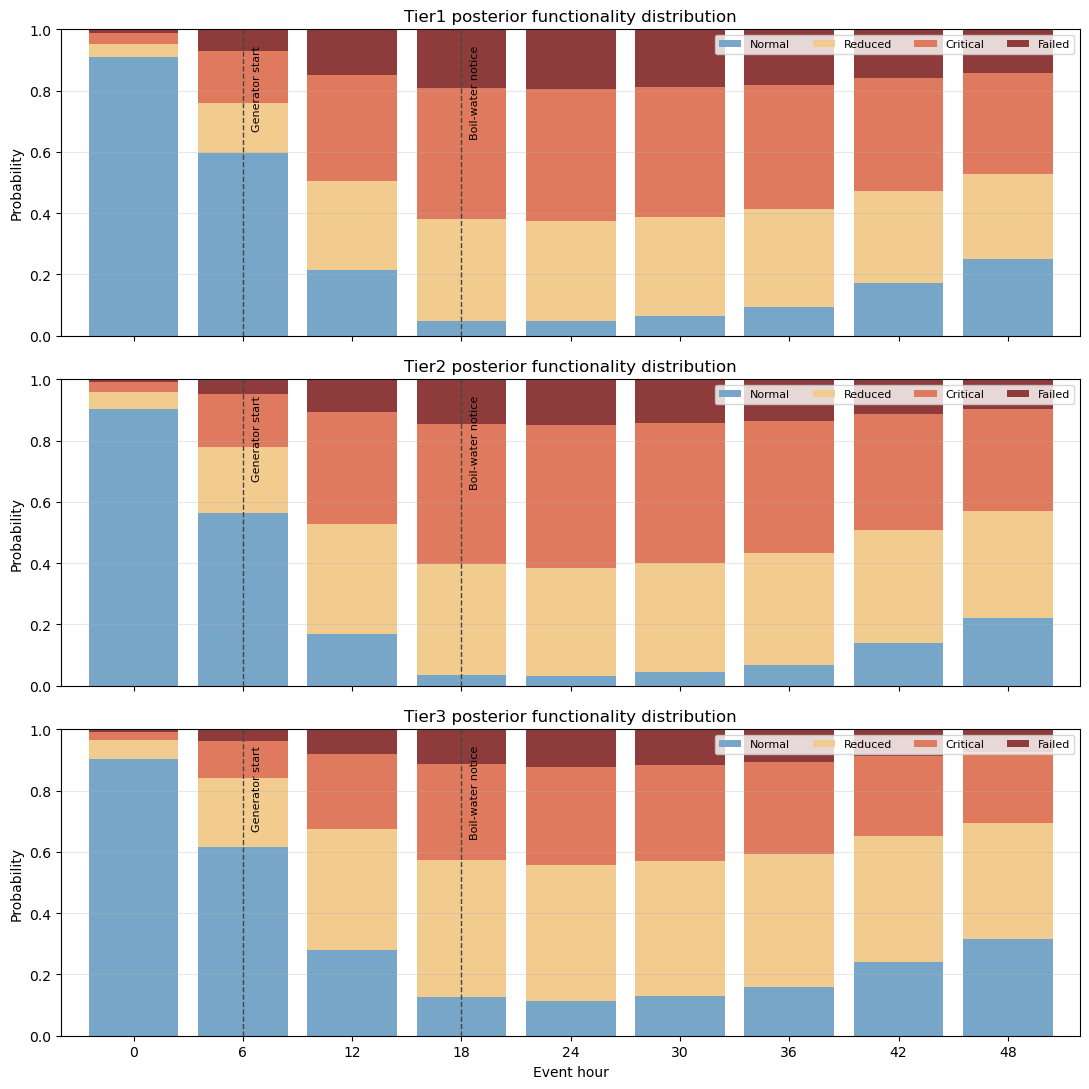

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(11, 11), sharex=True)
tier_names = ["Tier1", "Tier2", "Tier3"]
colors = ["#78a6c8", "#f2cc8f", "#e07a5f", "#8d3b3b"]

for ax, tier in zip(axes, tier_names):
    plot_df = posterior_evidence_summary.set_index("event_hour")[
        [
            f"P_{tier}_Functionality_Normal",
            f"P_{tier}_Functionality_Reduced",
            f"P_{tier}_Functionality_Critical",
            f"P_{tier}_Functionality_Failed",
        ]
    ]
    plot_df.columns = functionality_states
    plot_df.plot(kind="bar", stacked=True, ax=ax, color=colors, width=0.82)
    ax.set_title(f"{tier} posterior functionality distribution")
    ax.set_ylabel("Probability")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)
    ax.axvline(1, color="#444444", linestyle="--", linewidth=1)
    ax.axvline(3, color="#444444", linestyle="--", linewidth=1)
    ax.text(1.08, 0.95, "Generator start", rotation=90, va="top", fontsize=8)
    ax.text(3.08, 0.95, "Boil-water notice", rotation=90, va="top", fontsize=8)
    ax.legend(loc="upper right", ncol=4, fontsize=8)

axes[-1].set_xlabel("Event hour")
axes[-1].set_xticklabels(posterior_evidence_summary["event_hour"], rotation=0)
plt.tight_layout()
plt.show()

**Interpretation of tier stacked charts**

Each chart sums to 1.0 at every event hour. Movement from Normal/Reduced toward Critical/Failed
indicates worsening operational risk. The vertical reference lines mark the generator-start and
boil-water observations, making it easier to see when observed evidence changes the tier
functionality distribution.

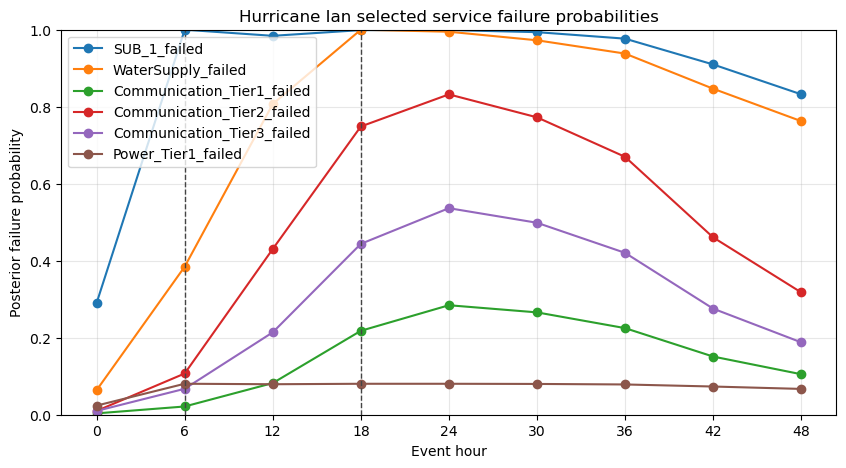

In [28]:
service_cols = ["P_SUB_1_failed", "P_WaterSupply_failed", "P_Communication_Tier1_failed", "P_Communication_Tier2_failed", "P_Communication_Tier3_failed", "P_Power_Tier1_failed"]
plt.figure(figsize=(10, 5))
for col in service_cols:
    plt.plot(dbn_results["event_hour"], dbn_results[col], marker="o", label=col.replace("P_", ""))
plt.axvline(6, color="#444444", linestyle="--", linewidth=1)
plt.axvline(18, color="#444444", linestyle="--", linewidth=1)
plt.xlabel("Event hour")
plt.ylabel("Posterior failure probability")
plt.title("Hurricane Ian selected service failure probabilities")
plt.xticks(dbn_results["event_hour"])
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Interpretation of service-probability chart**

The service chart shows which infrastructure services drive the tier results. A high
`WaterSupply_failed` probability is especially important because the model assumes no water backup.
`Power_Tier1_failed` remains much lower than `SUB_1_failed` during the 48-hour window because
generators are assumed to remain within their 5-day runtime.

## 9. Redundancy and hardening strategy simulation

The same network can be used for planning by changing selected assumptions and rerunning the
time-series prior forecast. Examples:

- Substation hardening: reduce `SUB_1_failed` flood/routine prior probabilities.
- Water backup: add emergency water storage, interconnection, or bottled-water logistics so WTP
  failure does not deterministically imply water-service failure.
- Telecom hardening: reduce failure probabilities for Lumen, Comcast, Lee dark fiber, and T-Mobile
  provider nodes through floodproofing, backup power, diverse routing, or portable network assets.
- Combined package: apply all three strategies together.

The strategy runs below intentionally use the no-observation DBN forecast. That makes the output a
planning comparison rather than a reconstruction conditioned on known observations.

In [29]:
strategy_definitions = {
    "Baseline": {},
    "Substation hardening": {"substation_own_multiplier": 0.55},
    "Water backup": {"water_backup_strength": 0.35, "water_routine_multiplier": 0.50},
    "Telecom hardening": {
        "root_multipliers": {
            "LEE_DARK_FIBER_failed": 0.65,
            "LUMEN_MPLS_failed": 0.65,
            "COMCAST_ENS_failed": 0.65,
            "COMCAST_BUSINESS_failed": 0.65,
            "TMOBILE_5G_failed": 0.65,
        },
        "comm_routine_multiplier": 0.60,
    },
    "Combined package": {
        "substation_own_multiplier": 0.55,
        "root_multipliers": {
            "LEE_DARK_FIBER_failed": 0.65,
            "LUMEN_MPLS_failed": 0.65,
            "COMCAST_ENS_failed": 0.65,
            "COMCAST_BUSINESS_failed": 0.65,
            "TMOBILE_5G_failed": 0.65,
        },
        "water_backup_strength": 0.35,
        "water_routine_multiplier": 0.50,
        "comm_routine_multiplier": 0.60,
    },
}


def apply_root_strategy(priors, strategy):
    priors = priors.copy()
    for var, multiplier in strategy.get("root_multipliers", {}).items():
        if var in priors:
            priors[var] = min(1.0, priors[var] * multiplier)
    return priors


def apply_substation_strategy(substation_own_probability, strategy):
    return min(1.0, substation_own_probability * strategy.get("substation_own_multiplier", 1.0))


def build_strategy_conditional_params(event_elapsed_hours, strategy, substation_own_failure_probability):
    params = build_conditional_params(
        event_elapsed_hours=event_elapsed_hours,
        substation_own_failure_probability=substation_own_failure_probability,
    )

    if "water_backup_strength" in strategy:
        params["WaterSupply_failed"] = {
            "type": "noisy_or",
            "parents": ["WTP_1_failed"],
            "strengths": [strategy["water_backup_strength"]],
            "routine_failure_probability": p_routine("WaterSupply_failed") * strategy.get("water_routine_multiplier", 1.0),
        }

    if "comm_routine_multiplier" in strategy:
        for var in ["Communication_Tier1_failed", "Communication_Tier2_failed", "Communication_Tier3_failed"]:
            params[var] = params[var].copy()
            params[var]["routine_failure_probability"] *= strategy["comm_routine_multiplier"]

    return params


def dbn_filter_strategy(strategy):
    time_steps = sorted(dbn_flood_depth["time_step"].unique())
    previous_root_posterior = None
    previous_substation_own_prior = None
    results = []

    for t in time_steps:
        event_hour = int(dbn_flood_depth.loc[dbn_flood_depth["time_step"] == t, "event_hour"].iloc[0])
        event_root_priors = apply_root_strategy(compute_fragility_priors_for_time(t), strategy)
        event_substation_own_prior = apply_substation_strategy(
            compute_substation_own_failure_probability_for_time(t),
            strategy,
        )

        if previous_root_posterior is None:
            dynamic_root_priors = event_root_priors.copy()
            dynamic_substation_own_prior = event_substation_own_prior
        else:
            dynamic_root_priors = {}
            for _, meta in root_variable_metadata.iterrows():
                var = meta["root_variable"]
                p_recover = transition_parameters.loc[
                    transition_parameters["node_type"] == meta["node_type"],
                    "p_recover_per_step",
                ].iloc[0]
                dynamic_root_priors[var] = temporal_update_root_prior(
                    previous_root_posterior[var],
                    event_root_priors[var],
                    p_recover,
                    event_hour,
                )
            substation_recover = transition_parameters.loc[
                transition_parameters["node_type"] == substation_own_metadata["node_type"],
                "p_recover_per_step",
            ].iloc[0]
            dynamic_substation_own_prior = temporal_update_root_prior(
                previous_substation_own_prior,
                event_substation_own_prior,
                substation_recover,
                event_hour,
            )

        params_t = build_strategy_conditional_params(
            event_elapsed_hours=event_hour,
            strategy=strategy,
            substation_own_failure_probability=dynamic_substation_own_prior,
        )
        binary_posteriors, tier_posteriors = evaluate_posteriors(evidence={}, priors=dynamic_root_priors, params=params_t)

        record = {"time_step": t, "event_hour": event_hour}
        for tier in tier_variables:
            record[f"{tier}_Critical_or_Failed"] = (
                tier_posteriors[tier]["Critical"] + tier_posteriors[tier]["Failed"]
            )
        record["WaterSupply_failed"] = binary_posteriors["WaterSupply_failed"]
        record["SUB_1_failed"] = binary_posteriors["SUB_1_failed"]
        record["Communication_Tier3_failed"] = binary_posteriors["Communication_Tier3_failed"]
        results.append(record)

        previous_root_posterior = {var: binary_posteriors[var] for var in root_priors}
        previous_substation_own_prior = dynamic_substation_own_prior

    return pd.DataFrame(results)


strategy_results = {
    name: dbn_filter_strategy(strategy)
    for name, strategy in strategy_definitions.items()
}

strategy_summary_rows = []
for name, df in strategy_results.items():
    for tier in ["Tier1_Functionality", "Tier2_Functionality", "Tier3_Functionality"]:
        col = f"{tier}_Critical_or_Failed"
        strategy_summary_rows.append({
            "strategy": name,
            "tier": tier.replace("_Functionality", ""),
            "max_P_Critical_or_Failed": df[col].max(),
            "event_hour_at_max": int(df.loc[df[col].idxmax(), "event_hour"]),
            "P_Critical_or_Failed_at_48h": float(df.loc[df["event_hour"] == 48, col].iloc[0]),
        })

strategy_summary = pd.DataFrame(strategy_summary_rows)
display(strategy_summary)

,strategy,tier,max_P_Critical_or_Failed,event_hour_at_max,P_Critical_or_Failed_at_48h
0,Baseline,Tier1,0.620264,24,0.471254
1,Baseline,Tier2,0.612681,24,0.428919
2,Baseline,Tier3,0.441116,24,0.303523
3,Substation hardening,Tier1,0.620129,24,0.471118
4,Substation hardening,Tier2,0.612544,24,0.428772
5,Substation hardening,Tier3,0.440827,24,0.303263
6,Water backup,Tier1,0.277950,24,0.192211
7,Water backup,Tier2,0.399600,24,0.225930
8,Water backup,Tier3,0.266476,24,0.152311
9,Telecom hardening,Tier1,0.607182,24,0.466297


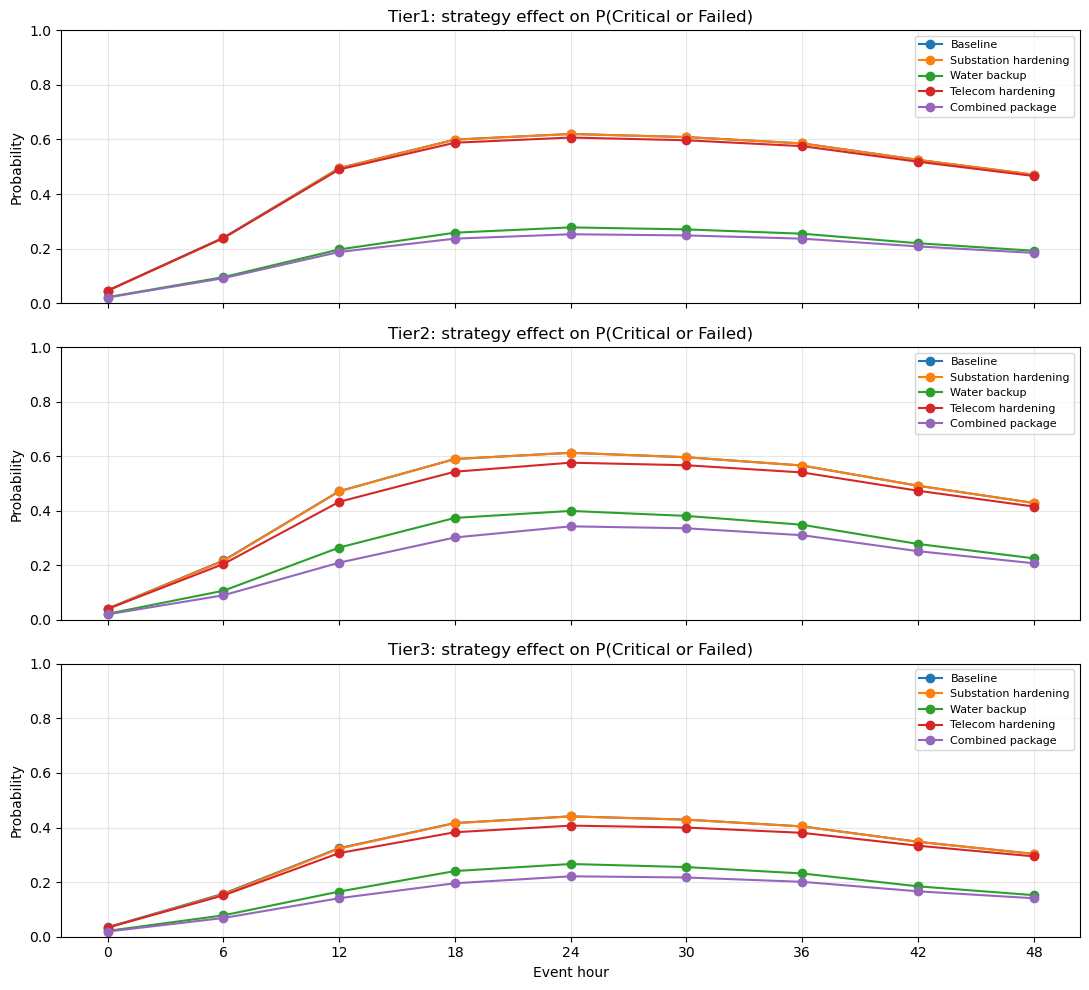

In [30]:
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
for ax, tier in zip(axes, ["Tier1_Functionality", "Tier2_Functionality", "Tier3_Functionality"]):
    col = f"{tier}_Critical_or_Failed"
    for name, df in strategy_results.items():
        ax.plot(df["event_hour"], df[col], marker="o", label=name)
    ax.set_title(f"{tier.replace('_Functionality', '')}: strategy effect on P(Critical or Failed)")
    ax.set_ylabel("Probability")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Event hour")
plt.xticks(strategy_results["Baseline"]["event_hour"])
plt.tight_layout()
plt.show()

**Interpretation of strategy simulation**

The strategy table compares the peak and final-hour probability that each tier is Critical or
Failed. Substation hardening primarily affects power-related pathways. Water backup has broad
benefits because water is shared and has no modeled backup in the baseline. Telecom hardening
mostly affects communication-driven degradation. The combined package shows how multiple
interventions can be represented by changing root priors and conditional service relationships in
the same BN/DBN structure.

## 10. What this toy example demonstrates

This revision demonstrates:

- a tiered HCI Bayesian Network that follows the revised dependency diagram;
- one visible `SUB_1_failed` node, with plant/transmission failure as the upstream parent and substation own failure as an internal CPT input;
- direct root failure priors from flood fragility plus routine failure logs;
- deterministic unavailability when an upstream provider chain fails;
- fuzzy expert elicitation only for independent dependency-chain strengths, with all elicitation questions documented;
- why prior inference is useful as a baseline risk forecast;
- why Monte Carlo simulation is useful as a scalable approximation to exact inference;
- posterior updating with generator-start evidence at hour 6 and boil-water evidence at hour 18;
- prior-vs-posterior DBN comparison to show how observations update estimated tier risk;
- separate stacked posterior charts for each facility tier;
- strategy simulation for substation hardening, water backup, telecom hardening, and combined interventions.